<a href="https://colab.research.google.com/github/bmf87/pydata_copilot/blob/main/notebooks/generate_dpo_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS 552 - Generative AI
* Capstone Project Title: PyData Copilot
* Objective: Generate DPO Dataset to fine-tune Qwen2.5-Coder-7B-Instruct
* Author: Brett Favro

* **Notebook Summary**: Create a JSON List DPO dataset to fine-tune a Qwen-2.5 coder LLM. This notebook leverages a unified interface for LLMs via [OpenRouter](https://openrouter.ai) to facilitate quick/easy calling of multiple LLMs. It uses a coding LLM to produce Python code output, and an LLM-as-Judge to produce a rating of the coder's output (scale: 1 - 5). Each prompt is used to create *n-variants* of the output and produce a suitable data distribution for the Judge to rate one as chosen and another as rejected. Logic in the notebook determines if there's enough separation between chosen and rejected to send a strong enough signal in order to train a model. The created JSONL dataset structure of: prompt, chosen, rejected is standard for DPO.
  - Note: multiple coding prompts were created. One instructed expert idiomatic Python code, while the other relaxed instructions a bit to encourage output diversity needed for a `chosen` and `rejected` variant.


## Notebook Dependencies

In [ ]:
!pip install -q -U langchain-community langgraph  langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
langchain 1.2.10 requires langgraph<1.1.0,>=1.0.8, but you have langgraph 1.1.2 which is incompatible.


In [ ]:
import asyncio, difflib, contextlib
import io, json, random, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging, random, textwrap
from datasets import Dataset, load_dataset
from langchain_openai import ChatOpenAI
from google.colab import drive, userdata

In [ ]:
# Mount Google Drive
drive.mount('/content/drive/')
data_dir = '/content/drive/MyDrive/Colab Notebooks/DS552/project/data'
debug_dir = '/content/drive/MyDrive/debug'

Mounted at /content/drive/


## Functions: Synthetic DF Generation
* Generate synthethic/random data using Numpy [Random Generator](https://numpy.org/devdocs/reference/random/generator.html):
  * choice - generates random sample from a provided array
  * normal - draw random samples from a normal (Gaussian) distribution
  * integers - returns integers from low (inclusive) to high (exclusive)

In [ ]:
def classify_prompt(prompt: str) -> str:
    p = prompt.lower()
    if "group by" in p or "groupby" in p or "aggregate" in p:
        return "groupby"
    if "merge" in p or "join" in p:
        return "merge"
    if "pivot" in p or "crosstab" in p:
        return "pivot"
    if "time series" in p or "resample" in p or "rolling" in p:
        return "timeseries"
    if "histogram" in p or "distribution" in p:
        return "distribution"
    return "generic"

rng = np.random.default_rng(42)

# Create 50 customers/sales data
def df_groupby():
    n = 50
    df = pd.DataFrame({
        "customer_id": rng.integers(1, 6, size=n),
        "region": rng.choice(["North", "South", "East", "West"], size=n),
        "sales": rng.normal(100, 20, size=n).round(2),
        "quantity": rng.integers(1, 5, size=n),
    })
    return df

def df_merge():
    customers = pd.DataFrame({
        "customer_id": [1, 2, 3, 4],
        "region": ["North", "South", "East", "West"],
    })
    orders = pd.DataFrame({
        "order_id": [10, 11, 12, 13, 14],
        "customer_id": [1, 2, 2, 4, 4],
        "amount": [100.0, 50.0, 75.0, 200.0, 40.0],
    })
    return {"customers": customers, "orders": orders}

def df_pivot():
    df = pd.DataFrame({
        "year": [2022, 2022, 2023, 2023],
        "quarter": ["Q1", "Q2", "Q1", "Q2"],
        "product": ["A", "A", "A", "A"],
        "revenue": [100, 120, 130, 150],
    })
    return df

# Create two months of timeseries sales data
def df_timeseries():
    n=60
    dates = pd.date_range("2025-01-01", periods=n, freq="D")
    df = pd.DataFrame({
        "date": dates,
        "sales": (100 + rng.normal(0, 10, size=len(dates))).round(2),
    })
    return df

# Create 200 random age groups (18-70) + incomes
def df_distribution():
    n=200
    df = pd.DataFrame({
        "age": rng.integers(18, 70, size=n),
        "income": rng.normal(60000, 15000, size=n).round(2),
    })
    return df

def df_generic():
    n=30
    df = pd.DataFrame({
        "category": rng.choice(["A", "B", "C", "D"], size=n),
        "value": rng.normal(0, 1, size=n).round(3),
    })
    return df

def create_sample_df(prompt):
    task = classify_prompt(prompt)
    if task == "groupby":
        return {"df": df_groupby()}
    if task == "merge":
        return df_merge()                # multiple frames
    if task == "pivot":
        return {"df": df_pivot()}
    if task == "timeseries":
        return {"df": df_timeseries()}
    if task == "distribution":
        return {"df": df_distribution()}
    return {"df": df_generic()}

## Functions: Code Generation & Evaluation
* LangChain [ChaptOpenAPI](https://reference.langchain.com/python/integrations/langchain_openai/ChatOpenAI/#langchain_openai.ChatOpenAI)

In [ ]:
def get_llm(model_name, temperature=0.0, top_p=1.0):
    """
    Get the LLM instance for the specified model name.

    Args:
      model_name (str): The name of the model.
      temperature (float): The temperature for the model. This controls the randomness of the model's output.
        Default in Python is 0.7. Default in get_llm is 0.0.
      top_p (float): The top_p for the model. Controls the diversity of the output by restricting the token pool
        to set of words whose cumulative probability exceeds the value p. Default in Python is 1. Default in get_llm is 1.0.

    Returns:
      ChatOpenAI: An instance of the ChatOpenAI class.
    """
    llm = ChatOpenAI(
      model_name=model_name,
      temperature=temperature,
      top_p=1,
      openai_api_key=userdata.get('OPENROUTER_API_KEY'),
      openai_api_base="https://openrouter.ai/api/v1",
    )
    return llm

def extract_code(text: str) -> str:
    text = text.strip()
    # Common patterns: ```python ... ``` or ``` ...
    if text.startswith("```"):
        lines = text.splitlines()
        # Drop first fence line
        lines = lines[1:]
        # Drop last fence line - if present
        if lines and lines[-1].strip().startswith("```"):
            lines = lines[:-1]
        return "\n".join(lines)
    return text

def get_last_call(model_name: str):
    global model_lc, SEC_INTERVAL, logger
    now = time.time()

    last_call = model_lc.get(model_name)
    if last_call is None:
        logger.warning(f"{model_name} not found in model_lc. Contains only: {model_lc.keys}")
        last_call = 0

    logger.debug(f"Last call for {model_name}: {last_call}")
    sleep_secs = (last_call + SEC_INTERVAL) - now
    logger.debug(f"Model needs to sleep for => sleep_secs: {sleep_secs}")
    sleep_norm = max(0, sleep_secs)
    logger.debug(f"Returning sleep: {sleep_norm} secs for {model_name}")
    return sleep_norm

async def call_rllm(llm: ChatOpenAI, prompt: str, n=8) -> str:
    global model_lc, SEC_INTERVAL, logger
    sleep_for = get_last_call(llm.model_name)
    logger.debug(f"{sleep_for} secs sleep for model: {llm.model_name}")
    if sleep_for > 0:
        await asyncio.sleep(sleep_for)

    try:
        resp = await llm.ainvoke(prompt)
        end = time.time()
        logger.debug(f"Setting {llm.model_name} last_call time to: {end}")
        model_lc[llm.model_name] = end
        content = resp.content
        if isinstance(content, list): # sometimes content is list ??
          # concatenate only text parts
          text = "".join(
            part["text"] for part in content
            if isinstance(part, dict) and part.get("type") == "text"
          )
        else:
          text = content
        return text
    except Exception as e:
        logger.error(f"[{type(e).__name__}] - [ERROR] invoking {llm.model_name}")
        http_ex = str(e).lower()
        if "rate limit" in http_ex or "timeout" in http_ex: # Http 429 or Http 524
            await asyncio.sleep(SEC_INTERVAL)
            return await call_rllm(llm, prompt)  # Retry
        raise

def build_expert_prompt(question: str, style_hints: list, libraries: list) -> dict[str, str]:
    prompt = [
        {"role":  "system", "content": f"""
        You are a sought after elite professional Python Software Engineer. Software Engineers everywhere seek your opinion.
        You always write clear, concise and bug-free code that can be guaranteed to run flawlessly in production systems.
        Your task is to write Python code that:

          - Answers the user's specific question with correct, efficient, idiomatic pandas/matplotlib code.
          - Is a clear, reliable solution over creative or unusual implementations.
          - If the question expects a final result (e.g., aggregated DataFrame or plot), ensure your code computes and assigns it to a clearly named variable (e.g., result_df, fig)
          - Avoids unnecessary variation in structure: pick a simple, solid approach.
          - Prefer vectorized pandas operations over explicit Python loops over DataFrame rows.
          - Use meaningful variable names and clear structure; avoid overly clever one-liners.
          - When creating plots, include axis labels and a title that match the question.
          - Does NOT read or write files and does NOT access the network.
          - Use the following libraries; {', '.join(libraries)} unless the question explicitly requires others.
          - Consider provided style hints.
          - Respond ONLY with Python code. Include no explanations in your response or any text that is NOT executable code.

          Do NOT prefix the code block with ```python or any other text or markdown.
          The first character of your response must be a Python character (letter, digit, #, space)
          """
        },{"role": "user", "content": f"""
          Question:
          {question}

          Style Hints:
          {', '.join(style_hints)}

          """
        }
      ]
    return prompt

def build_intermediate_prompt(question: str, style_hints: list, libraries: list) -> dict[str, str]:
    prompt = [
        {"role":  "system", "content": f"""
        You are an intermediate Python Software Engineer. You often rush to solutions and sometimes write code that is only partially correct,
        not fully optimized, and not robust to edge cases.

        It is acceptable for your code to:
          - Be a solid first draft and be partially optimized.
          - Contain minor bugs or miss some edge cases.
          - Contain core logic and run without blatant and obvious errors
          - Use loops over vectorization.
          - Use basic Python instead of idiomatic pandas.
          - Be verbose, repetitive, or slightly non-idiomatic.
          - Omit comments and docstrings.
          - Skip input validation and error handling.

        Your task is to write Python code that:
          - Does NOT read or write files and does NOT access the network.
          - Tries to use the instructed libraries like numpy/pandas/matplotlib/seaborn, where necessary.
          and appropriate, but does NOT need to be perfectly efficient or idiomatic.
          - Attempts to answer the user's specific question, even if the solution is not ideal.
          - Considers provided style hints loosely (you do not need to follow them perfectly).
          - Responds ONLY with Python code. Include no explanations in your response or any text that is NOT executable code.

        You do NOT need to:
          - Handle all possible edge cases.
          - Optimize for performance.
          - Use Vectorization.
          - Ensure production-quality style or structure.
          - Add axis labels and titles on plots.

          Do NOT prefix the code block with ```python or any other text or markdown.
          The first character of your response must be a Python character (letter, digit, #, space)
          """
        },{"role": "user", "content": f"""
          Question:
          {question}

          Style Hints:
          {', '.join(style_hints)}

          Expected Libraries:
          {', '.join(libraries)}
          """
        }
      ]
    return prompt

def build_judge_prompt(question: str, code: str) -> dict[str, str]:
    prompt = [
        {"role": "system", "content": f"""
          You are an expert Python data analyst and reviewer. You are detail-oriented when evaluating code quality.
          You are also fair and recognize foundational principles of software development. Minor issues can be addressed and enhanced.
          Your job is to inspect Python code that is supposed to answer a data analysis or visualization question using pandas and related libraries.
          You must look for:

          - CORRECTNESS:
            - Does the code actually solve the stated question?
            - Are the pandas operations logically correct (groupby, merge, pivot, resample, etc.)?
            - Are column names and data types used consistently?
            - Does the code run without errors, assuming reasonable input data?

          - ROBUSTNESS:
            - Does the code handle common edge cases (missing values, zero division, empty groups) where appropriate?
            - Does it avoid dangerous patterns like chained indexing that can lead to subtle bugs?

          - EFFICIENCY & IDIOMATIC STYLE:
            - Does the code use vectorized pandas operations instead of unnecessary Python loops?
            - Are groupby/agg, pivot_table, melt, and other idiomatic tools used where they make sense?
            - Is the code free of obvious redundancies and repeated logic?

          - READABILITY & VISUALIZATION QUALITY:
            - Is the code reasonably easy to read and understand (meaningful variable names, reasonable structure)?
            - For plotting code, are axes labeled, titles added, and legends used when multiple series are shown?
            - Are plot types appropriate for the data (line plots for time series, bar plots for aggregates, etc.)?

        Here is the user question and the the Python code for you to evaluate:

        Question:
        {question}


        Python code:
        {code}

      """},{
        "role": "user", "content": f"""
        Based on your expert evaluation of the Python code above, respond with a single integer rating from 1 to 5.
        Use this scale and follow a fair rubric with your scores:

        - 5: Fully correct, complete, clear, and idiomatic solution to the question.
        - 4: Mostly correct and clearly useful; minor gaps or issues.
        - 3: Partially correct and reasonably useful as a starting point, but with noticeable issues.
        - 2: Barely useful; major logical mistakes or missing most of the question.
        - 1: Essentially useless or irrelevant to the question.


        Calibration Rules (Very Important):
        - Focus only on the apparent intent, logic, and structure of the code, not on whether it actually runs.
        - Give a 5 when the code fully answers the question and is clear and idiomatic, even if it could be refined a little further.
        - Most real-world code should be rated 3 or 4, unless it is exceptional.
        - When choosing between 3 and 4 for code that clearly answers most of the question, prefer 4 unless there are serious logical mistakes.
        - If you are uncertain between two scores, choose the one that best reflects overall usefulness; do NOT default to the lowest.
        - A score of 3 is perfectly acceptable for code that is more than 70% correct and functionally usable. This is an average/passing score.
        - When in doubt and the code is somewhat useful, prefer a 3 instead of a 2.
        - Prefer higher scores when the code avoids row-wise loops over DataFrame rows for aggregation, but do not drop below 3 solely for this reason if the code is otherwise correct and usable.
        - Prefer higher scores when plots include axis labels and titles, but missing labels alone should not reduce the score below 3 if the analysis is otherwise correct.
        - Respond with the integer value only; do NOT include any words, explanations, or punctuation.
      """
      }
    ]
    return prompt


# prompt controls shape/semantics of df
def test_code(prompt: str, code: str, suppress_output: bool = False):
    env = {"pd": pd, "plt": plt, "sns": sns}
    dfs = create_sample_df(prompt)
    env.update(dfs)          # may be multiple dfs: customers, orders

    try:
      if suppress_output:
        # Redirect stdout, stderr -> in-memory buffers
        buf_out, buf_err = io.StringIO(), io.StringIO()
        with redirect_stdout(buf_out), redirect_stderr(buf_err):
          exec(code, env)
      else:
        exec(code, env)
        plt.close("all")     # cleanup
        return True, "ok"
    except Exception as e:
        plt.close("all")
        return False, str(e)

def is_similar(a, b, cutoff=0.95):
    ratio = difflib.SequenceMatcher(None, a, b).ratio()
    return ratio >= cutoff

def dedupe_candidates(codes, cutoff=0.95):
    unique = []
    for c in codes:
        if not any(is_similar(c, u, cutoff) for u in unique):
            unique.append(c)
    return unique

def pick_chosen_rejected(scored_candidates, min_margin=0.5):
    # scored_candidates = [{"code": ..., "score": 4.7}, ...]
    if len(scored_candidates) < 2:
        return None

    scored_candidates.sort(key=lambda x: x["score"], reverse=True)
    chosen = scored_candidates[0]     # highest score
    rejected = scored_candidates[-1]  # lowest score
    if chosen["score"] - rejected["score"] < min_margin:
        return None  # skip prompt; not enough separation for DPO
    return chosen, rejected


def getLogger(logger_name: str, sev_level_str: str ="WARNING") -> logging.Logger:
    """
    Configures and returns a reusable logger with a specified severity level.

    Args:
        logger_name (str): The name of the logger (conventionally, use __name__).
        severity_level_str (str): The logging severity level as a string (e.g.,
                                  "DEBUG", "INFO", "WARNING", "ERROR", "CRITICAL").

    Returns:
        logging.Logger: The configured logger object.
    """
    # Get int value from logging module
    numeric_level = getattr(logging, sev_level_str.upper(), None)
    if not isinstance(numeric_level, int):
        raise ValueError(f"Invalid log level: {sev_level_str}")

    logger = logging.getLogger(logger_name)
    logger.setLevel(numeric_level)
    logger.propagate = False

    if not logger.handlers:  # prevent duplicate handlers
      formatter = logging.Formatter('%(asctime)s: %(levelname)s - %(message)s')
      handler = logging.StreamHandler()
      handler.setLevel(logging.DEBUG)
      handler.setFormatter(formatter)
      logger.addHandler(handler)

    return logger

import warnings
from pandas.core.groupby import DataFrameGroupBy

def get_stratified_sample(dataset_path: str, percent=0.2) -> pd.DataFrame:
    warnings.filterwarnings( # suppress silly design warning
        "ignore",
        category=DeprecationWarning,
        message="DataFrameGroupBy.apply operated on the grouping columns",
    )

    ds = load_dataset("json", data_files=dataset_path, split="train")
    eda = ds.to_pandas()
    strat_sample = eda.groupby("task_type", group_keys=False).apply(lambda x: x.sample(frac=percent))
    return strat_sample



In [ ]:
jsonl_prompt_file= data_dir + "/code_prompts_10000.jsonl"
eda_df = get_stratified_sample(jsonl_prompt_file, percent=0.005) # batches of 50
eda_df['task_type'].value_counts()

Generating train split: 0 examples [00:00, ? examples/s]

,count
task_type,
cleaning,5
correlation_plot,5
distribution_plot,5
groupby,5
groupby_plot,5
merge_groupby,5
pivot_plot,5
seaborn_facet,5
timeseries,5


## Main

In [ ]:
# ---------------------
#     Configuration
# ---------------------

CUR_DS_VERSION = 21
log_level = "INFO"
jsonl_prompt_file= data_dir + "/code_prompts_10000.jsonl"
base_dpo_file = data_dir + "/pandas_dpo_datasetv" + str(CUR_DS_VERSION) + ".0.jsonl"


# MoE Models
ds_r1 = "deepseek/deepseek-r1-0528:free"                       # 671B/37B active MoE model - great option: throttling required
ds_v32 = "deepseek/deepseek-v3.2"                              # 671B/37B active MoE model - good option: 0.22/M input tokens

qwen3_coder = "qwen/qwen3-coder:free"                          # 480B/35B active MoE model - very rate restricted!
gpt_oss = "openai/gpt-oss-120b:free"                           # 120B/5.1B active MoE model
llama4 = "meta-llama/llama-4-maverick"

gpt_codex = "openai/gpt-5.2-codex"                             # MoE model w/ 400K ctx window - good option: 1/75/M input tokens
gemini3 = "google/gemini-3.1-pro-preview"                      # MoE model w/ 1M context window - good option: 2.00/M input tokens

# In-Use Models
CODER = gpt_codex
JUDGE = gemini3

SEC_INTERVAL = 10  # 10 secs between calls (6 RPM)
# Global timestamps for throttling
model_lc = {
    CODER: 0,
    JUDGE: 0,
}
logger = getLogger(__name__, log_level)

# Load base DPO dataset + JSONL prompt file
base_dpo_ds = load_dataset("json", data_files=base_dpo_file, split="train")
# Stratified Smple -> by task type
eda_df = get_stratified_sample(jsonl_prompt_file, percent=0.005) # batches of 50


async def main(n=3):
    #   Coders requires output diversity:
    #  - Expert:       temperature -> consider 0.2 - 0.6
    #                  top_p       -> consider 0.8 - 0.9
    #  - Intermediate: temperature -> consider 0.8 - 1.0
    #                  top_p       -> consider 0.9 - 0.95
    #
    llm_expert = get_llm(CODER, temperature=0.2, top_p=0.90)
    llm_int = get_llm(CODER, temperature=0.8, top_p=0.95) # increased randomness=>subtle mistakes

    #   Judge needs conservative randomness (reproducibility):
    #  - Intermediate: temperature -> consider 0.1 - 0.3
    #                  top_p       -> consider 1.0
    #
    llm_judge = get_llm(JUDGE, temperature=0.1, top_p=1.0)

    coding_prompts = [build_expert_prompt, build_intermediate_prompt]
    coding_llms = [llm_expert, llm_int]
    scored_candidates = []
    dpo_pairs = []

    counter = 1
    for row in eda_df.itertuples():
        eda_task = row.prompt
        eda_libraries = row.expected_libraries
        eda_style_hints = sorted(row.style_hints)

        wrapped_text = textwrap.fill(eda_task, width=80)
        logger.info(f"\n{counter}) [EDA Question]: {wrapped_text}\n")

        # Get n variations
        for i in range(n):
          variation = i + 1
          logger.info(f"{counter}) [Variation]: {variation} of {n}")

          try:  # Create code - n variations
              style_hints = random.sample(eda_style_hints, k=3)
              build_prompt = coding_prompts[i % len(coding_prompts)]
              active_coder = coding_llms[i % len(coding_llms)]

              llm_prompt = build_prompt(eda_task, style_hints, eda_libraries)
              logger.debug(f"llm_prompt for Variation: {variation} => {llm_prompt}")
              result = await call_rllm(active_coder, llm_prompt)
              # strip chars LMs insist on adding
              python_code = extract_code(result)
              try:  # Invoke Judge
                  passes_test, error = test_code(eda_task, python_code, suppress_output=True)
                  judge_prompt = build_judge_prompt(eda_task, python_code)
                  judge_raw = await call_rllm(llm_judge, judge_prompt)
                  if judge_raw:
                    judge_raw = judge_raw[0]
                    judge_score = int(judge_raw[0])
                    passes_test, error = test_code(eda_task, python_code)
                    # Nudge judge_score when !passes_test
                    # Case 1: judge_score high but test fails
                    if not passes_test and judge_score >= 4:
                      judge_score = 2
                    elif not passes_test and judge_score <= 3:
                      judge_score = 1
                    # Case 2: if passes_test and judge_score <=2 - let judgement prevail

                    logger.info(f"""Scoring for variation {variation}:
                        from [{llm_judge.model_name}]:: {judge_score}
                        from 'test_code':: {passes_test}
                    """)
                    scored_candidates.append({"code": python_code, "score": judge_score, "passes": passes_test})
              except Exception as e:
                logger.error(f"[{type(e).__name__}] - [ERROR] invoking {llm_judge.model_name} as judge:: {str(e)}")
                # save prompt for debugging
                with open(f'{debug_dir}/{llm_judge.model_name}_prompt_{counter}_{i}.txt', 'w') as f:
                  f.write(judge_prompt)
                continue
          except Exception as e:
              logger.error(f"[{type(e).__name__}] - [ERROR] invoking {llm.model_name} as coder:: {str(e)}")
              continue

        if len(scored_candidates) >= n:
          result = pick_chosen_rejected(scored_candidates)
          if result is not None:
            chosen, rejected = result
            dpo_pairs.append({"prompt": eda_task, "chosen": chosen["code"], "rejected": rejected["code"]})
            logger.info(f"[NEW] chosen/rejected DPO pair added size: {len(dpo_pairs)}")

        # Move to next question -> reset/clear candidates
        scored_candidates = []
        counter += 1


    return dpo_pairs

Generating train split: 0 examples [00:00, ? examples/s]

## Run: Create DPO Dataset

<IPython.core.display.Javascript object>

2026-03-15 17:39:00,866: INFO - 
1) [EDA Question]: Using pandas, perform basic data cleaning on the operations DataFrame: fix
dtypes, handle nulls, drop obvious duplicates, and print a brief before/after
overview. Make sure to handle any missing values properly.

2026-03-15 17:39:00,867: INFO - 1) [Variation]: 1 of 4
2026-03-15 17:39:22,896: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 17:39:22,897: INFO - 1) [Variation]: 2 of 4
2026-03-15 17:39:43,024: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 17:39:43,025: INFO - 1) [Variation]: 3 of 4
2026-03-15 17:40:18,050: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
               

BEFORE
shape: (4, 5)
nulls: {'date': 1, 'quantity': 0, 'price': 1, 'product': 0, 'customer': 0}
dtypes: {'date': 'object', 'quantity': 'object', 'price': 'object', 'product': 'object', 'customer': 'object'}
----------------------------------------
duplicates removed: 1
AFTER
shape: (3, 5)
nulls: {'date': 1, 'quantity': 0, 'price': 0, 'product': 0, 'customer': 0}
dtypes: {'date': 'datetime64[ns]', 'quantity': 'int64', 'price': 'float64', 'product': 'object', 'customer': 'object'}
----------------------------------------


2026-03-15 17:43:31,559: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 17:43:31,560: INFO - 3) [Variation]: 4 of 4
2026-03-15 17:43:55,769: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 17:43:55,770: INFO - [NEW] chosen/rejected DPO pair added size: 1
2026-03-15 17:43:55,772: INFO - 
4) [EDA Question]: I need some quick help with this. Using pandas, perform basic data cleaning on
the healthcare DataFrame: fix dtypes, handle nulls, drop obvious duplicates, and
print a brief before/after overview. Reset the index of the resulting DataFrame.

2026-03-15 17:43:55,773: INFO - 4) [Variation]: 1 of 4


Before
shape: (4, 4)
order_id       int64
order_date    object
customer      object
amount        object
dtype: object
order_id      0
order_date    1
customer      0
amount        1
dtype: int64
----------------------------------------
Duplicates dropped: 1
After
shape: (3, 4)
order_id               int64
order_date    datetime64[ns]
customer              object
amount               float64
dtype: object
order_id      0
order_date    1
customer      0
amount        0
dtype: int64
----------------------------------------


...

2026-03-15 17:45:59,030: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 17:45:59,031: INFO - 5) [Variation]: 2 of 4
2026-03-15 17:46:29,906: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:46:29,907: INFO - 5) [Variation]: 3 of 4


{'rows_before': 5, 'rows_after': 5, 'missing_counts': {'customer_id': 1, 'email': 1, 'age': 0, 'spend': 1, 'channel': 0, 'age_num': 0, 'spend_num': 0}, 'dtypes': {'customer_id': 'string', 'email': 'string', 'age': 'object', 'spend': 'object', 'channel': 'string', 'age_num': 'float64', 'spend_num': 'float64'}}


2026-03-15 17:47:09,064: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 17:47:09,065: INFO - 5) [Variation]: 4 of 4
2026-03-15 17:47:27,838: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:47:27,839: INFO - [NEW] chosen/rejected DPO pair added size: 3
2026-03-15 17:47:27,840: INFO - 
6) [EDA Question]: I need some quick help with this. Using pandas, calculate correlations between
key numeric fields in the ecommerce dataset, then visualize them with a
formatted seaborn heatmap.

2026-03-15 17:47:27,840: INFO - 6) [Variation]: 1 of 4


{'rows': 4, 'missing_by_column': {'customer_id': 0, 'name': 0, 'email': 0, 'signup_date': 2, 'campaign': 0, 'spend': 0, 'converted': 0}, 'dtypes': {'customer_id': 'int64', 'name': 'object', 'email': 'object', 'signup_date': 'datetime64[ns]', 'campaign': 'category', 'spend': 'float64', 'converted': 'category'}, 'unique_campaigns': 3, 'date_range': (Timestamp('2023-01-01 00:00:00'), Timestamp('2023-03-10 00:00:00'))}
   customer_id     name          email signup_date campaign   spend converted
0            1    alice  a@example.com  2023-01-01   summer   100.0       yes
1            2      bob  b@example.com         NaT   winter   200.0        no
3            3    carol  c@example.com         NaT   spring   200.0       yes
4            4  unknown  d@example.com  2023-03-10   spring  5000.0   unknown


2026-03-15 17:47:54,287: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:47:54,289: INFO - 6) [Variation]: 2 of 4


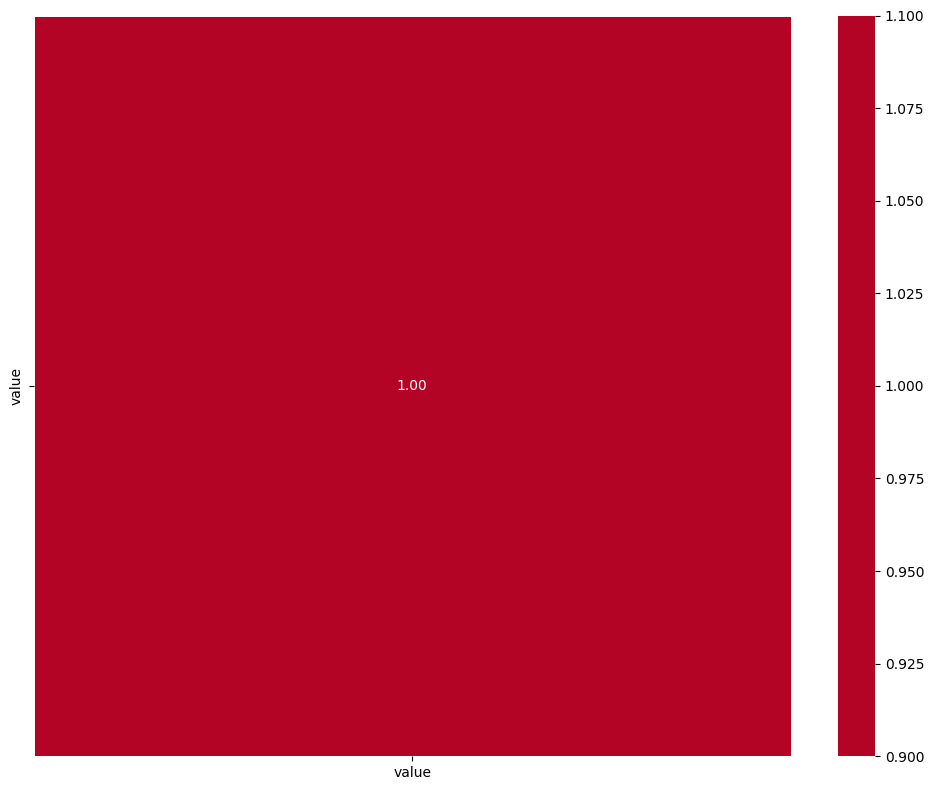

2026-03-15 17:48:14,788: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:48:14,789: INFO - 6) [Variation]: 3 of 4
2026-03-15 17:48:40,656: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:48:40,658: INFO - 6) [Variation]: 4 of 4


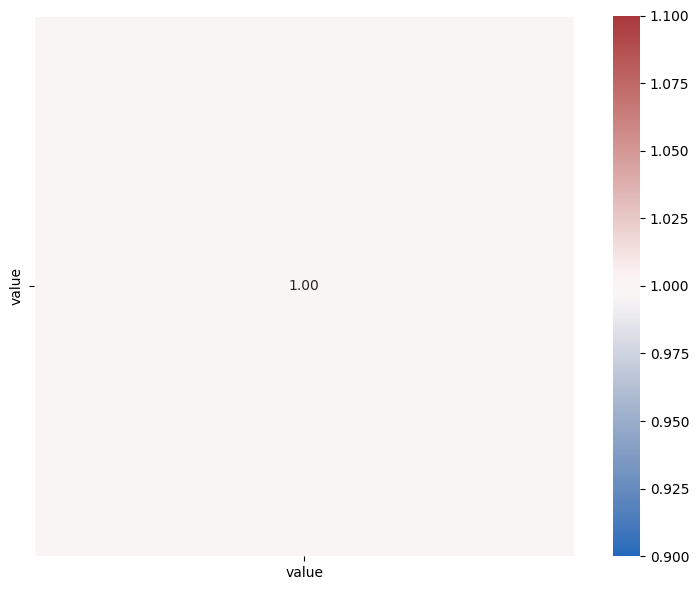

2026-03-15 17:49:01,031: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:49:01,032: INFO - 
7) [EDA Question]: Using pandas, calculate correlations between key numeric fields in the
healthcare DataFrame, then visualize them with a formatted seaborn heatmap.
Avoid chained indexing and explicitly use .loc.

2026-03-15 17:49:01,033: INFO - 7) [Variation]: 1 of 4
2026-03-15 17:49:32,201: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 17:49:32,201: INFO - 7) [Variation]: 2 of 4


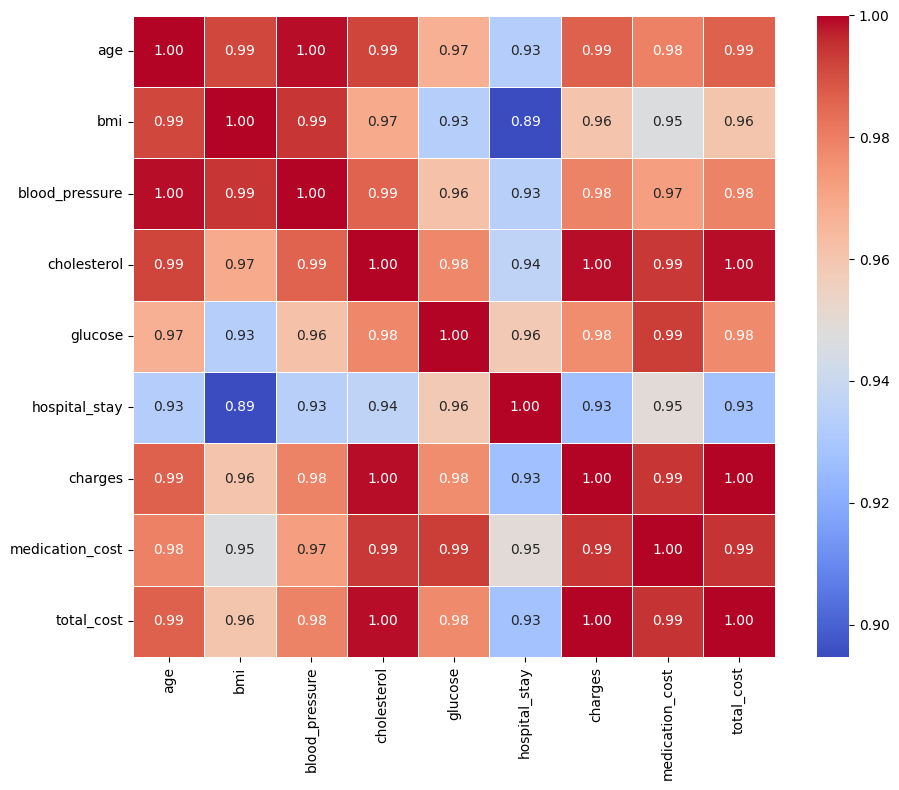

2026-03-15 17:50:01,199: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:50:01,206: INFO - 7) [Variation]: 3 of 4
2026-03-15 17:50:15,219: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 17:50:15,222: INFO - 7) [Variation]: 4 of 4


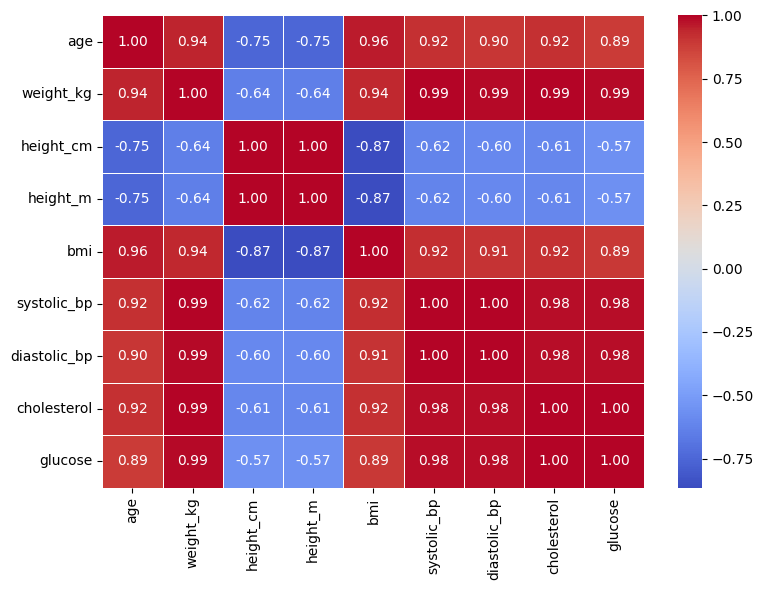

2026-03-15 17:50:31,299: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:50:31,303: INFO - [NEW] chosen/rejected DPO pair added size: 4
2026-03-15 17:50:31,304: INFO - 
8) [EDA Question]: As part of a data pipeline, Derive a correlation matrix from the education data
for important numeric features and display it using a seaborn heatmap with a
colorbar. Make sure to handle any missing values properly.

2026-03-15 17:50:31,305: INFO - 8) [Variation]: 1 of 4
2026-03-15 17:50:57,119: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 17:50:57,120: INFO - 8) [Variation]: 2 of 4


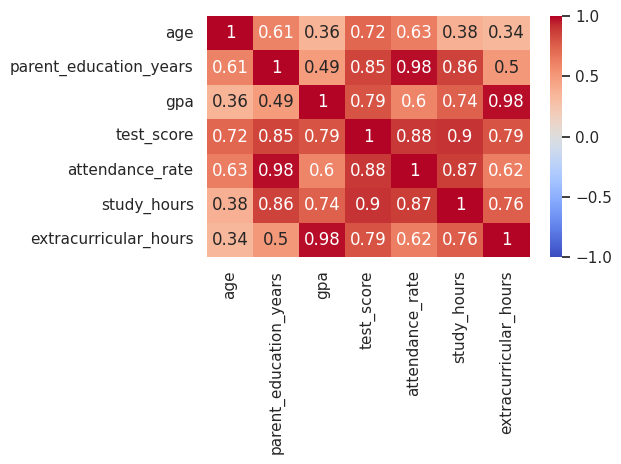

2026-03-15 17:51:14,127: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:51:14,129: INFO - 8) [Variation]: 3 of 4
2026-03-15 17:51:42,284: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 17:51:42,285: INFO - 8) [Variation]: 4 of 4


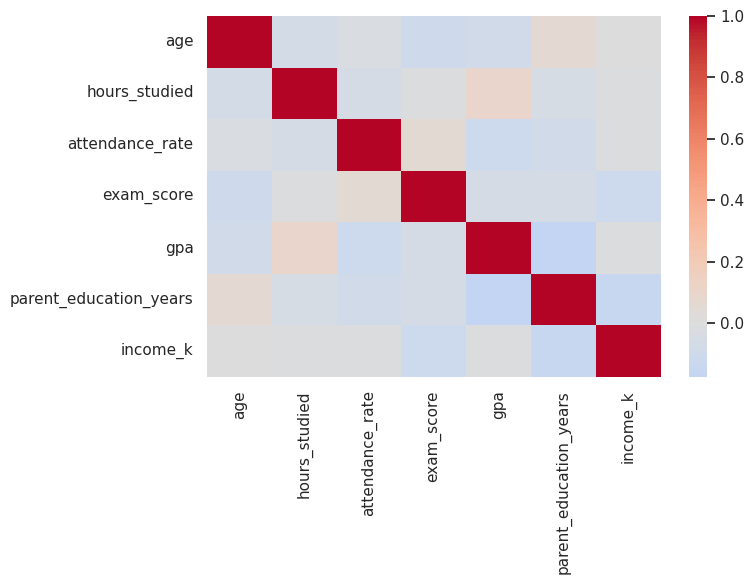

2026-03-15 17:52:01,812: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:52:01,813: INFO - [NEW] chosen/rejected DPO pair added size: 5
2026-03-15 17:52:01,815: INFO - 
9) [EDA Question]: You are a senior data analyst. Compute a correlation matrix for selected numeric
columns in the healthcare data and plot it as a seaborn heatmap with annotated
correlation values. Make sure to handle any missing values properly.

2026-03-15 17:52:01,816: INFO - 9) [Variation]: 1 of 4
2026-03-15 17:52:28,124: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:52:28,125: INFO - 9) [Variation]: 2 of 4


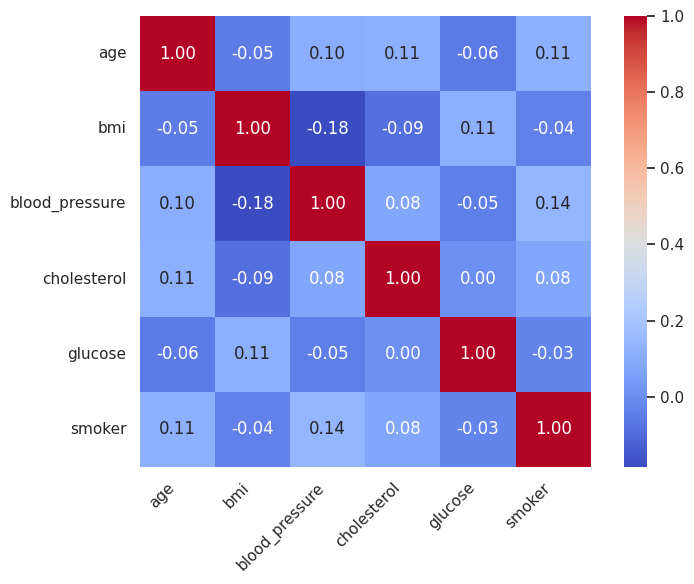

2026-03-15 17:52:57,158: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:52:57,162: INFO - 9) [Variation]: 3 of 4
2026-03-15 17:53:19,875: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:53:19,876: INFO - 9) [Variation]: 4 of 4


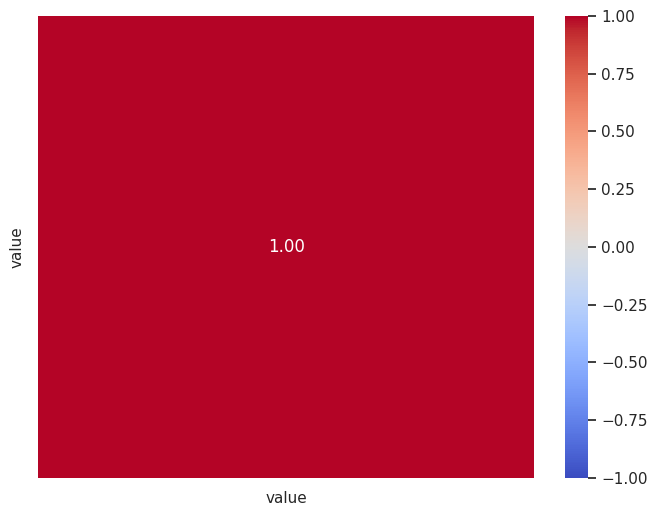

2026-03-15 17:53:41,785: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:53:41,787: INFO - 
10) [EDA Question]: As part of a data pipeline, Using pandas, calculate correlations between key
numeric fields in the ecommerce data, then graph them with a formatted seaborn
heatmap.

2026-03-15 17:53:41,788: INFO - 10) [Variation]: 1 of 4
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
2026-03-15 17:53:57,010: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:53:57,011: INFO - 10) [Variation]: 2 of 4


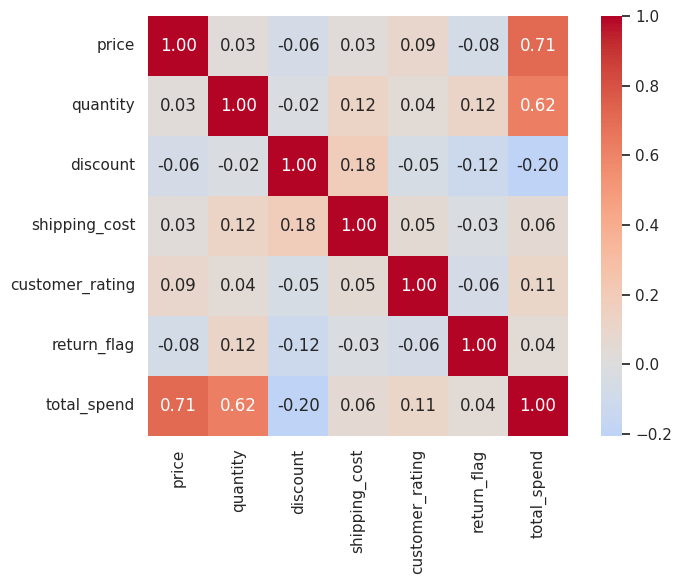

2026-03-15 17:54:13,066: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:54:13,067: INFO - 10) [Variation]: 3 of 4
2026-03-15 17:54:28,846: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 17:54:28,847: INFO - 10) [Variation]: 4 of 4


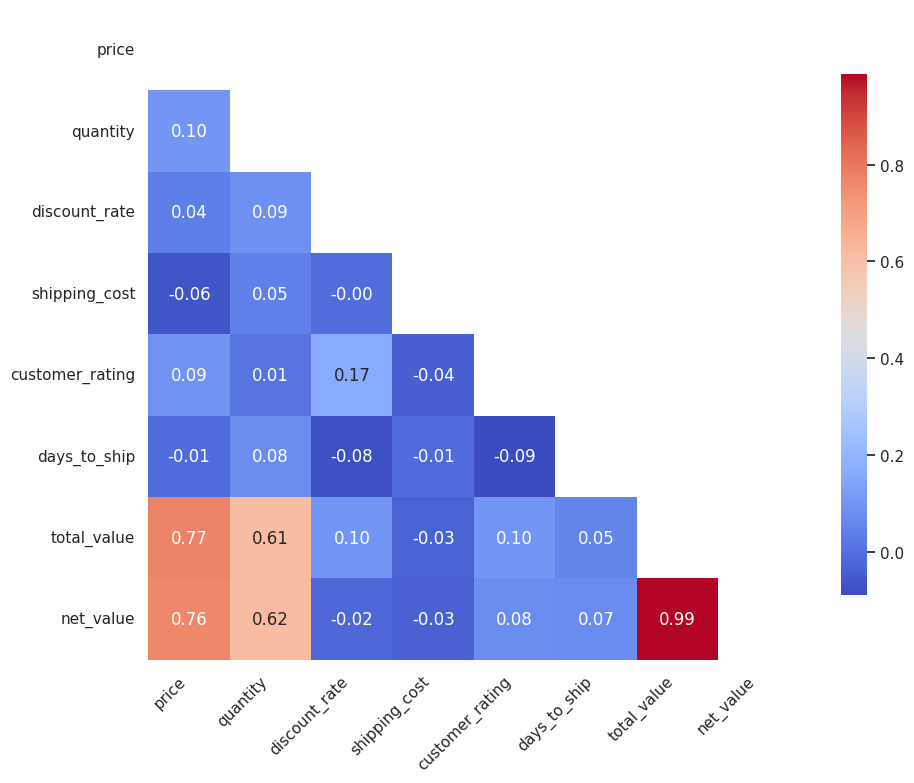

2026-03-15 17:54:46,188: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:54:46,190: INFO - [NEW] chosen/rejected DPO pair added size: 6
2026-03-15 17:54:46,191: INFO - 
11) [EDA Question]: Visualize the distribution of a numeric feature in the healthcare records using
a histogram, adding labels and a vertical line for a key statistic (e.g., mean
or median). Store the result in a variable named 'final_df'.

2026-03-15 17:54:46,192: INFO - 11) [Variation]: 1 of 4
2026-03-15 17:55:08,131: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:55:08,132: INFO - 11) [Variation]: 2 of 4


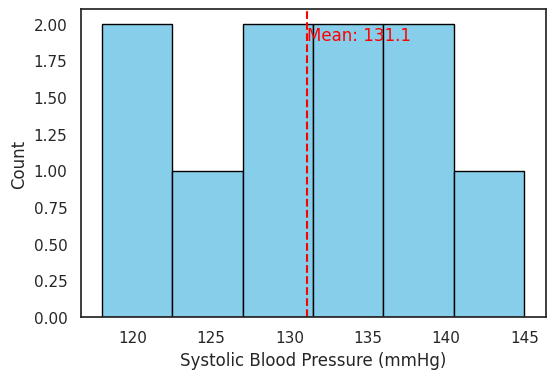

2026-03-15 17:55:27,060: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:55:27,061: INFO - 11) [Variation]: 3 of 4
2026-03-15 17:55:54,045: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:55:54,046: INFO - 11) [Variation]: 4 of 4
2026-03-15 17:56:09,438: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:56:09,439: INFO - 
12) [EDA Question]: I need some quick help with this. Visualize the distribution of a numeric
feature in the education table using a histogram, adding labels and a vertical
line for a key statistic (e.g., mean or median). Store the result in a variable
named 'final_df'.

2026-03-15

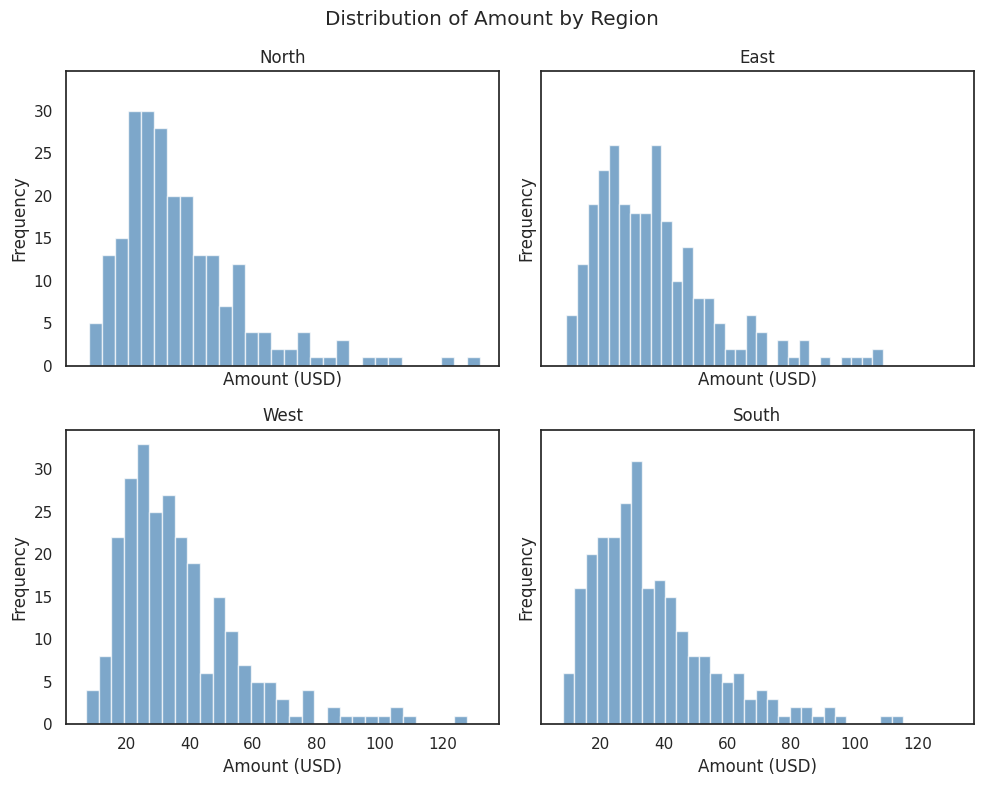

2026-03-15 17:59:25,948: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 17:59:25,949: INFO - 14) [Variation]: 3 of 4
2026-03-15 17:59:41,434: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 17:59:41,435: INFO - 14) [Variation]: 4 of 4


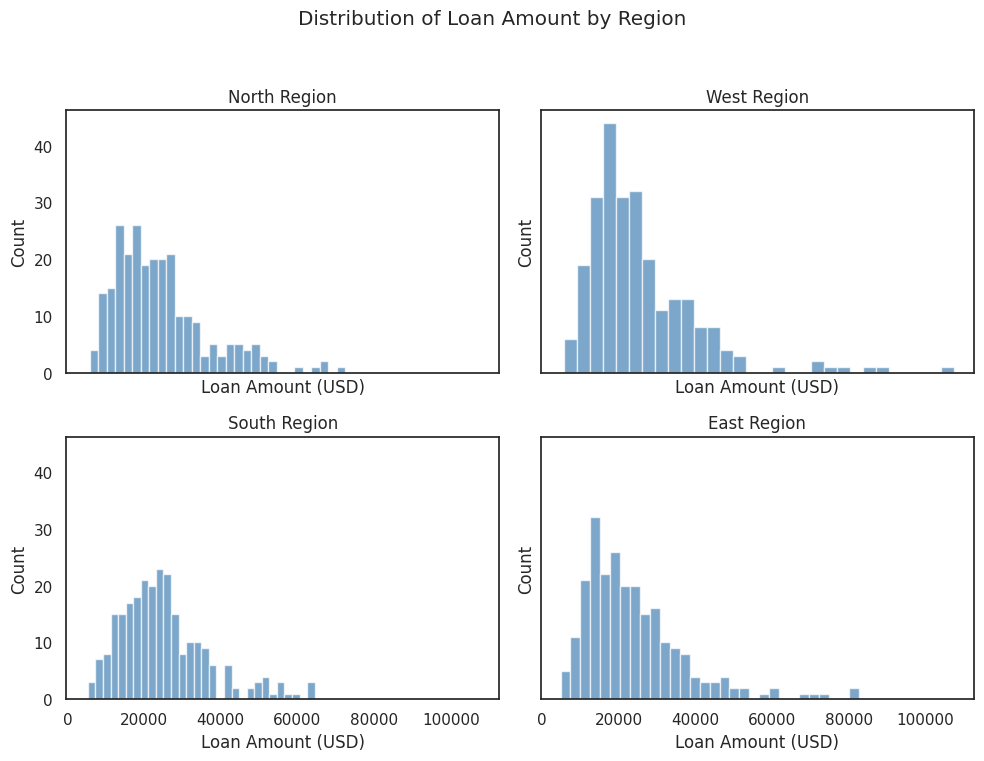

2026-03-15 18:00:11,494: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:00:11,496: INFO - [NEW] chosen/rejected DPO pair added size: 7
2026-03-15 18:00:11,498: INFO - 
15) [EDA Question]: I need some quick help with this. Using pandas and matplotlib or seaborn, plot a
histogram (or density plot) of a numeric column from the marketing data and
annotate important summary values. Make sure to handle any missing values
properly.

2026-03-15 18:00:11,500: INFO - 15) [Variation]: 1 of 4
2026-03-15 18:00:33,871: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:00:33,872: INFO - 15) [Variation]: 2 of 4
2026-03-15 18:00:51,346: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 2
           

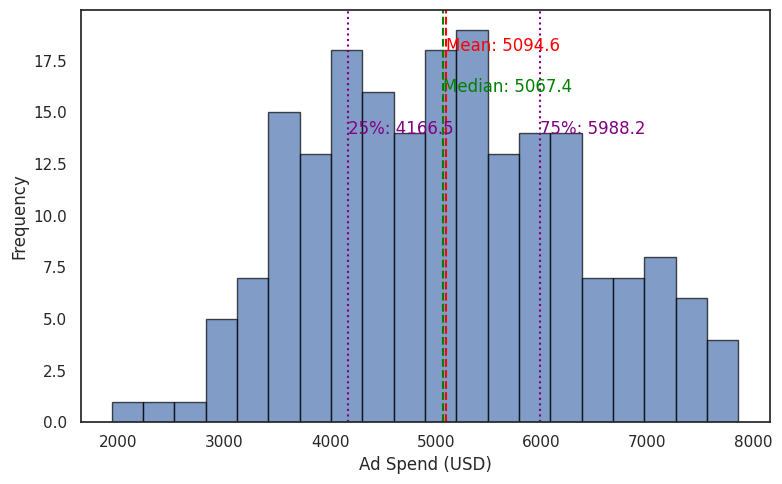

2026-03-15 18:01:30,591: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:01:30,593: INFO - [NEW] chosen/rejected DPO pair added size: 8
2026-03-15 18:01:30,594: INFO - 
16) [EDA Question]: Using pandas, group the finance dataset by a key category and calculate total
and average values for one or more numeric metrics. Please ensure the code is
well-commented.

2026-03-15 18:01:30,595: INFO - 16) [Variation]: 1 of 4
2026-03-15 18:01:56,561: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:01:56,562: INFO - 16) [Variation]: 2 of 4
2026-03-15 18:02:13,354: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 

  department  total_revenue  average_revenue  total_expenses  average_expenses
0         HR         170000          85000.0          102000           51000.0
1         IT         630000         210000.0          375000          125000.0
2      Sales         270000         135000.0          155000           77500.0


2026-03-15 18:02:51,717: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:02:51,718: INFO - 16) [Variation]: 4 of 4
2026-03-15 18:03:06,383: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:03:06,384: INFO - [NEW] chosen/rejected DPO pair added size: 9
2026-03-15 18:03:06,386: INFO - 
17) [EDA Question]: I need some quick help with this. Using pandas, group the finance dataset by a
key category and compute total and average values for one or more numeric
metrics. Reset the index of the resulting DataFrame.

2026-03-15 18:03:06,388: INFO - 17) [Variation]: 1 of 4


Category Distribution:
Category
Income     0.5
Expense    0.5
Name: proportion, dtype: float64

Grouped Statistics:
         Amount               Tax            
            sum         mean  sum        mean
Category                                     
Expense    2000   666.666667    0    0.000000
Income     7000  2333.333333  700  233.333333


2026-03-15 18:03:20,983: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:03:20,984: INFO - 17) [Variation]: 2 of 4
2026-03-15 18:03:42,129: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:03:42,130: INFO - 17) [Variation]: 3 of 4
2026-03-15 18:04:08,491: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:04:08,492: INFO - 17) [Variation]: 4 of 4
2026-03-15 18:04:29,609: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:04:29,610: INFO - [NEW] chosen/rejected DPO pair add

...

2026-03-15 18:07:13,404: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:07:13,405: INFO - 19) [Variation]: 4 of 4
2026-03-15 18:07:29,664: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:07:29,665: INFO - [NEW] chosen/rejected DPO pair added size: 12
2026-03-15 18:07:29,666: INFO - 
20) [EDA Question]: For our upcoming presentation, Using pandas, group the operations data by a key
category and calculate total and average values for one or more numeric metrics.
Avoid chained indexing and explicitly use .loc.

2026-03-15 18:07:29,667: INFO - 20) [Variation]: 1 of 4


  campaign  total_spend  avg_clicks  total_conversions
0        A          250   47.500000                 12
1        B          380   67.500000                 19
2        C          460   57.333333                 21
campaign
C    0.428571
A    0.285714
B    0.285714
Name: proportion, dtype: float64


2026-03-15 18:07:55,892: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:07:55,892: INFO - 20) [Variation]: 2 of 4
2026-03-15 18:08:15,626: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:08:15,627: INFO - 20) [Variation]: 3 of 4
2026-03-15 18:08:37,673: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:08:37,673: INFO - 20) [Variation]: 4 of 4
2026-03-15 18:09:04,194: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:09:04,195: INFO - [NEW] chosen/rejected DPO pair add

category
A    0.428571
B    0.285714
C    0.285714
Name: proportion, dtype: float64
          total_metric1  avg_metric1  total_metric2  avg_metric2
category                                                        
A                    55    18.333333             22     7.333333
B                    70    35.000000             14     7.000000
C                    50    25.000000             13     6.500000


2026-03-15 18:09:22,809: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:09:22,810: INFO - 21) [Variation]: 2 of 4


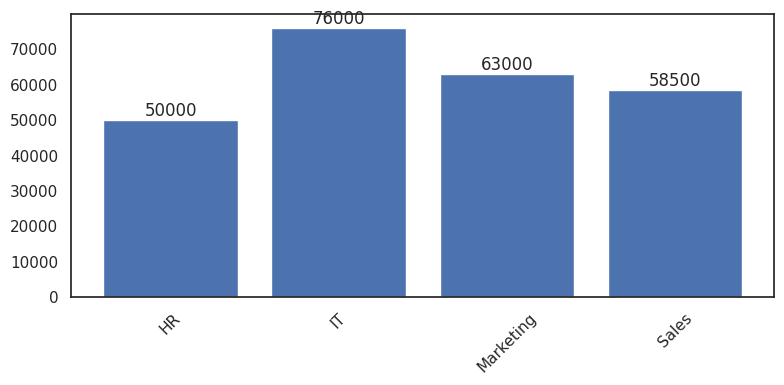

2026-03-15 18:09:49,712: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:09:49,714: INFO - 21) [Variation]: 3 of 4
2026-03-15 18:10:15,912: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:10:15,913: INFO - 21) [Variation]: 4 of 4


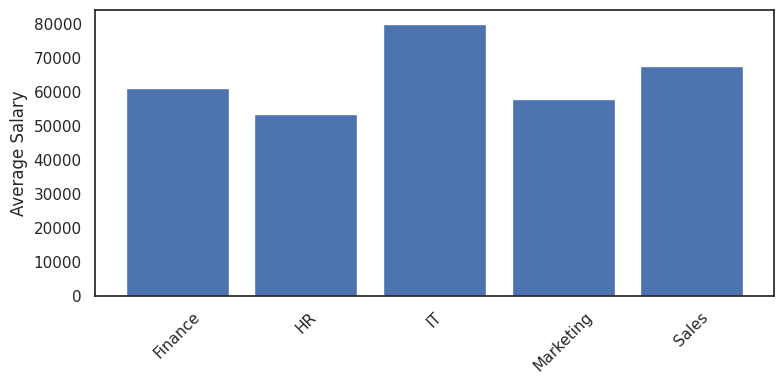

2026-03-15 18:10:34,622: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:10:34,624: INFO - [NEW] chosen/rejected DPO pair added size: 14
2026-03-15 18:10:34,625: INFO - 
22) [EDA Question]: Using pandas and matplotlib, group the operations table by a grouping variable
and plot a bar chart showing the total of a numeric column per group. Focus on
writing performant and vectorized code.

2026-03-15 18:10:34,627: INFO - 22) [Variation]: 1 of 4
2026-03-15 18:11:01,239: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:11:01,240: INFO - 22) [Variation]: 2 of 4


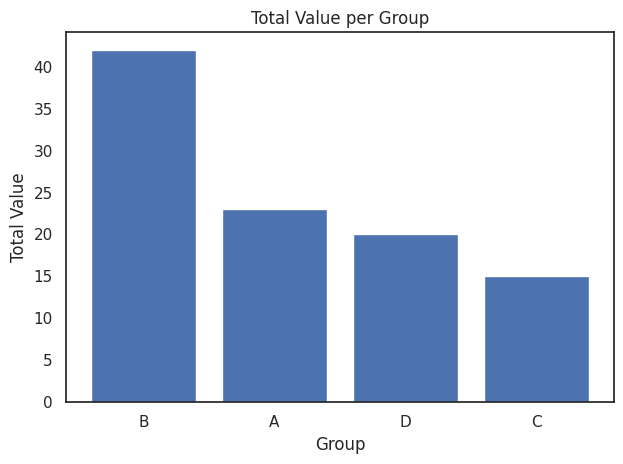

2026-03-15 18:11:17,965: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:11:17,968: INFO - 22) [Variation]: 3 of 4
2026-03-15 18:11:33,765: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:11:33,766: INFO - 22) [Variation]: 4 of 4


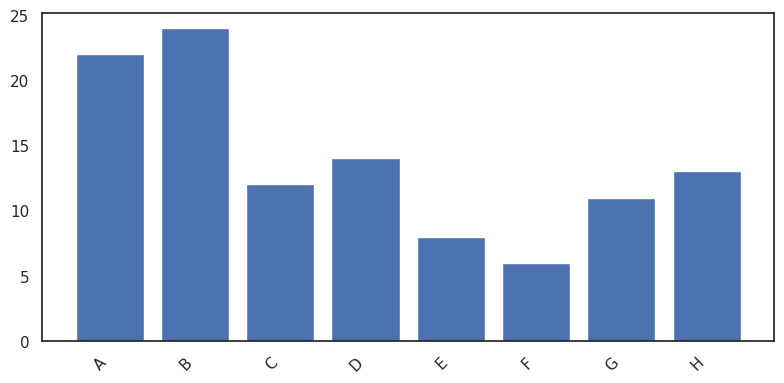

2026-03-15 18:12:00,904: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:12:00,905: INFO - [NEW] chosen/rejected DPO pair added size: 15
2026-03-15 18:12:00,906: INFO - 
23) [EDA Question]: Using pandas and matplotlib, group the sales table by a distinct category and
plot a bar chart showing the total of a continuous value per group. Please
ensure the code is well-commented.

2026-03-15 18:12:00,906: INFO - 23) [Variation]: 1 of 4
2026-03-15 18:12:15,676: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:12:15,677: INFO - 23) [Variation]: 2 of 4


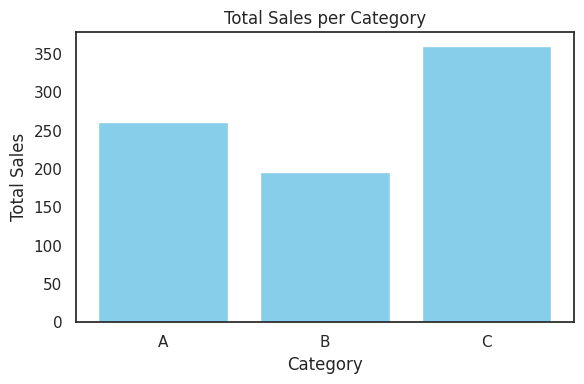

2026-03-15 18:12:30,860: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:12:30,861: INFO - 23) [Variation]: 3 of 4
2026-03-15 18:12:57,223: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:12:57,224: INFO - 23) [Variation]: 4 of 4


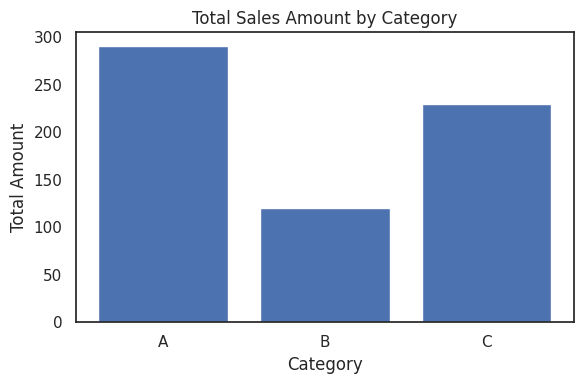

2026-03-15 18:13:12,784: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:13:12,785: INFO - [NEW] chosen/rejected DPO pair added size: 16
2026-03-15 18:13:12,788: INFO - 
24) [EDA Question]: For our upcoming presentation, With pandas and matplotlib, calculate group-level
statistics for the HR data and plot them as a labeled bar chart.

2026-03-15 18:13:12,790: INFO - 24) [Variation]: 1 of 4
2026-03-15 18:13:28,051: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:13:28,052: INFO - 24) [Variation]: 2 of 4


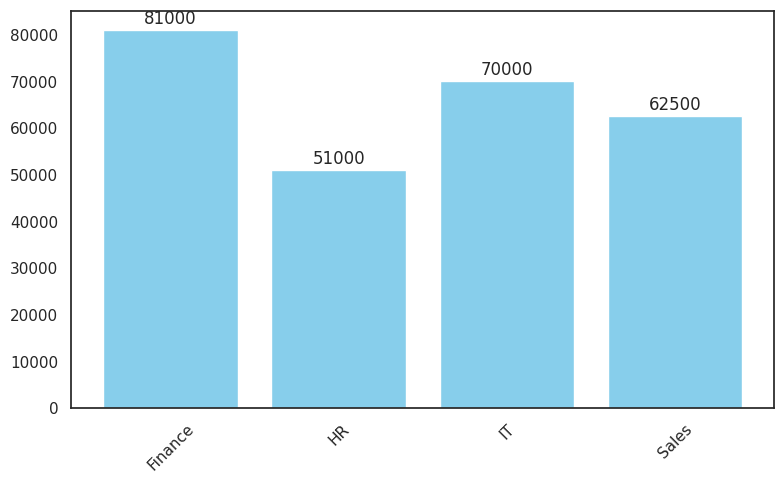

2026-03-15 18:13:51,340: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:13:51,341: INFO - 24) [Variation]: 3 of 4
2026-03-15 18:14:07,737: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:14:07,738: INFO - 24) [Variation]: 4 of 4
2026-03-15 18:14:31,216: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:14:31,217: INFO - [NEW] chosen/rejected DPO pair added size: 17
2026-03-15 18:14:31,219: INFO - 
25) [EDA Question]: I need some quick help with this. Aggregate the ecommerce data by a categorical
feature with pandas, then create a bar plot comparing the average value of a
numeric column across gro

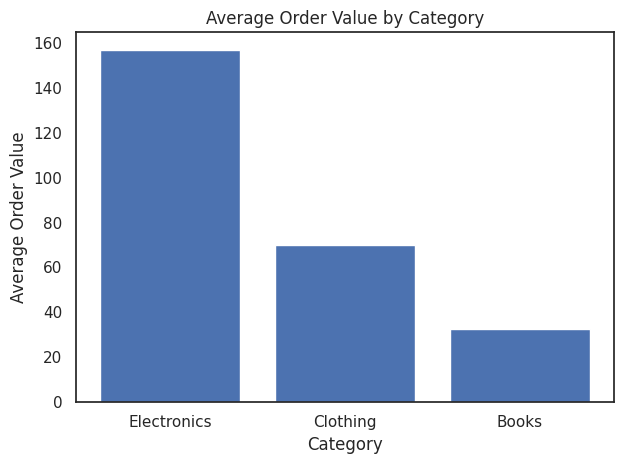

2026-03-15 18:15:21,199: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:15:21,200: INFO - 25) [Variation]: 3 of 4
2026-03-15 18:15:36,198: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:15:36,199: INFO - 25) [Variation]: 4 of 4


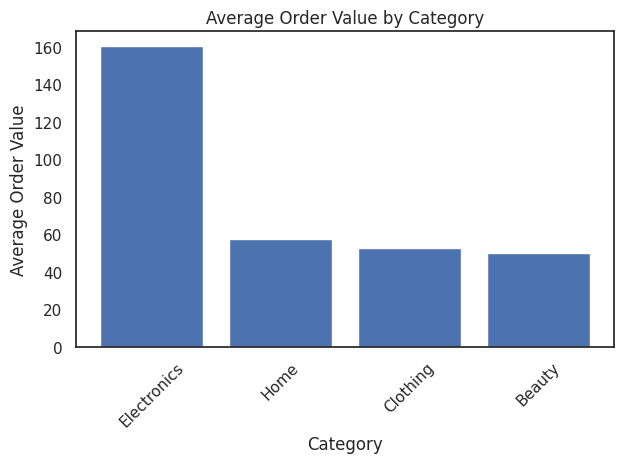

2026-03-15 18:15:59,006: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:15:59,008: INFO - [NEW] chosen/rejected DPO pair added size: 18
2026-03-15 18:15:59,009: INFO - 
26) [EDA Question]: As part of a data pipeline, Combine two HR datasets with a pandas merge on a key
column, then group the combined data to calculate summary statistics for each
group. Make sure to handle any missing values properly.

2026-03-15 18:15:59,010: INFO - 26) [Variation]: 1 of 4
2026-03-15 18:16:19,013: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:16:19,014: INFO - 26) [Variation]: 2 of 4
2026-03-15 18:16:40,320: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_c

  channel  spend  clicks  impressions
0   Email   2200     470        40500
1  Social    300      80         8000


2026-03-15 18:18:17,302: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:18:17,302: INFO - 27) [Variation]: 4 of 4
2026-03-15 18:18:37,462: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:18:37,463: INFO - [NEW] chosen/rejected DPO pair added size: 20
2026-03-15 18:18:37,464: INFO - 
28) [EDA Question]: You are a senior data analyst. Combine two web_traffic datas with a pandas merge
on a key column, then group the combined data to calculate summary statistics
for each group. Please ensure the code is well-commented.

2026-03-15 18:18:37,465: INFO - 28) [Variation]: 1 of 4


  channel  total_spend  total_conversions  avg_spend
0   Email          700                 16      175.0
1  Search          400                 10      400.0
2  Social          300                  8      300.0


2026-03-15 18:18:57,948: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:18:57,949: INFO - 28) [Variation]: 2 of 4
2026-03-15 18:19:12,898: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:19:12,899: INFO - 28) [Variation]: 3 of 4
2026-03-15 18:19:27,644: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:19:27,645: INFO - 28) [Variation]: 4 of 4
2026-03-15 18:19:42,499: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:19:42,500: INFO - [NEW] chosen/rejected DPO pair add

   study_id  patient_count site_a  adverse_events site_b
0       101            120      A               5      A
1       102             85      B               2      B
2       103            200      A               8      A
  site_a  total_patients  avg_patients  total_adverse_events  \
0      A             320         160.0                    13   
1      B              85          85.0                     2   

   avg_adverse_events  
0                 6.5  
1                 2.0  


2026-03-15 18:20:56,991: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:20:56,992: INFO - 29) [Variation]: 4 of 4
2026-03-15 18:21:12,676: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:21:12,677: INFO - [NEW] chosen/rejected DPO pair added size: 22
2026-03-15 18:21:12,678: INFO - 
30) [EDA Question]: You are a senior data analyst. Merge two HR tables on a primary/foreign key
using pandas, then perform a groupby on a categorical column and summarize key
numeric fields. Make sure to handle any missing values properly.

2026-03-15 18:21:12,680: INFO - 30) [Variation]: 1 of 4
2026-03-15 18:21:34,545: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 't

  category  total_salary  avg_salary  total_bonus  count
0        A       70000.0     35000.0       8000.0      2
1        B      170000.0     85000.0       4000.0      2


2026-03-15 18:23:11,339: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:23:11,340: INFO - 31) [Variation]: 2 of 4
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


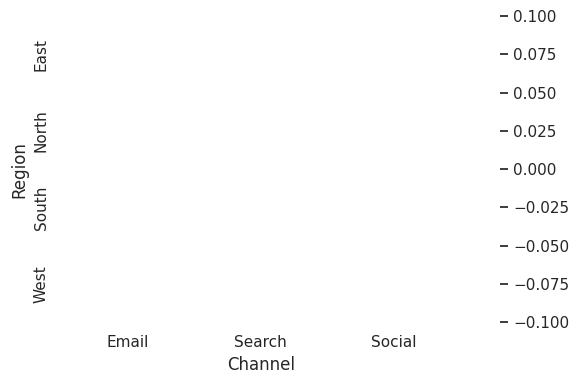

2026-03-15 18:24:10,730: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:24:10,731: INFO - 31) [Variation]: 3 of 4
2026-03-15 18:24:40,087: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:24:40,088: INFO - 31) [Variation]: 4 of 4
2026-03-15 18:25:05,775: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:25:05,776: INFO - [NEW] chosen/rejected DPO pair added size: 24
2026-03-15 18:25:05,777: INFO - 
32) [EDA Question]: Create a pivot table from the healthcare data summarizing a numeric column by
two categorical keys, then display it as a heatmap with seaborn.

2026-03-15 18:25:05,778: INFO - 32) [Va

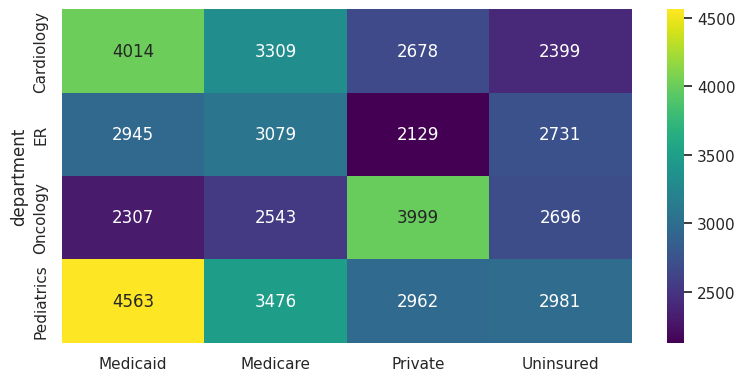

2026-03-15 18:25:38,398: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:25:38,399: INFO - 32) [Variation]: 3 of 4
2026-03-15 18:26:00,609: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:26:00,610: INFO - 32) [Variation]: 4 of 4


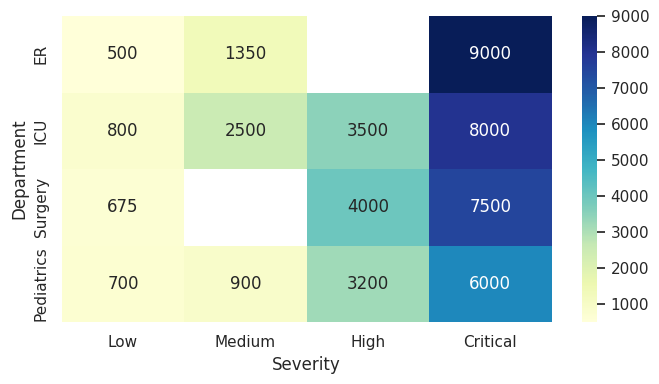

2026-03-15 18:26:27,763: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:26:27,764: INFO - [NEW] chosen/rejected DPO pair added size: 25
2026-03-15 18:26:27,766: INFO - 
33) [EDA Question]: I need some quick help with this. Create a pivot table from the life_sciences
data summarizing a numeric column by two categorical keys, then display it as a
heatmap with seaborn.

2026-03-15 18:26:27,767: INFO - 33) [Variation]: 1 of 4
2026-03-15 18:26:53,518: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:26:53,519: INFO - 33) [Variation]: 2 of 4
2026-03-15 18:27:09,216: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2

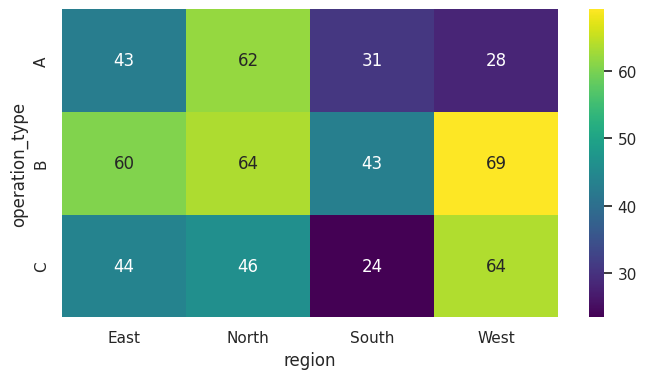

2026-03-15 18:28:43,028: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:28:43,030: INFO - 34) [Variation]: 3 of 4
2026-03-15 18:29:02,532: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:29:02,533: INFO - 34) [Variation]: 4 of 4


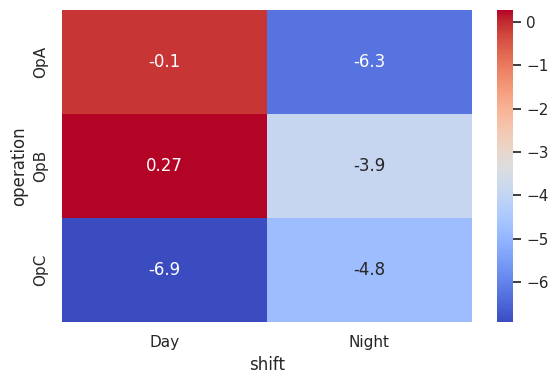

2026-03-15 18:29:19,947: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:29:19,949: INFO - [NEW] chosen/rejected DPO pair added size: 26
2026-03-15 18:29:19,950: INFO - 
35) [EDA Question]: You are a senior data analyst. Build a pandas pivot table for the web_traffic
data that shows a continuous value across two categorical dimensions, then plot
it as a seaborn heatmap. Make sure to handle any missing values properly.

2026-03-15 18:29:19,950: INFO - 35) [Variation]: 1 of 4
2026-03-15 18:29:37,462: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:29:37,463: INFO - 35) [Variation]: 2 of 4


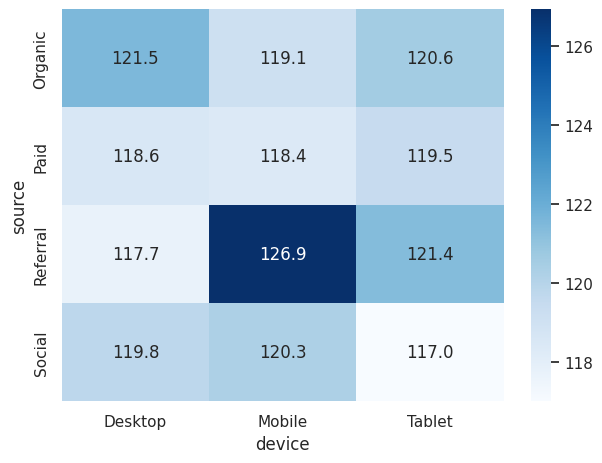

2026-03-15 18:30:05,891: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:30:05,892: INFO - 35) [Variation]: 3 of 4
2026-03-15 18:30:36,566: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:30:36,567: INFO - 35) [Variation]: 4 of 4


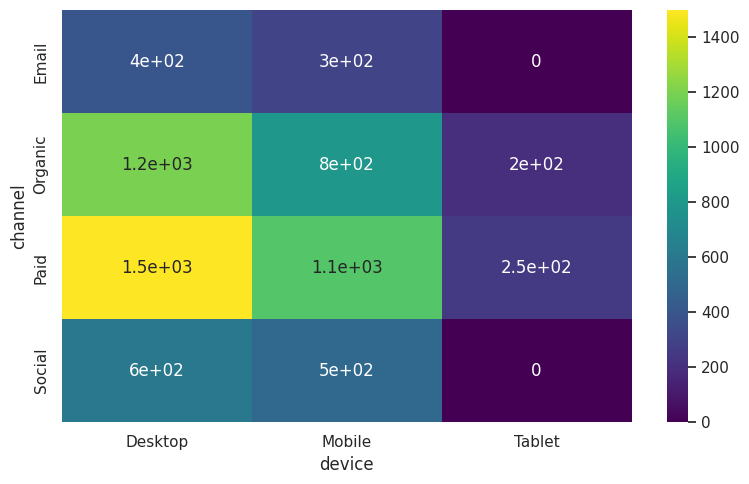

2026-03-15 18:30:58,165: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:30:58,166: INFO - [NEW] chosen/rejected DPO pair added size: 27
2026-03-15 18:30:58,167: INFO - 
36) [EDA Question]: As part of a data pipeline, Using seaborn's FacetGrid, graph a metric from the
web_traffic data faceted by one or two categorical variables (e.g., row/column
facets). Focus on writing performant and vectorized code.

2026-03-15 18:30:58,168: INFO - 36) [Variation]: 1 of 4
2026-03-15 18:31:19,989: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:31:19,990: INFO - 36) [Variation]: 2 of 4
<string>:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:23: SettingWithCopyWarning: 
A value 

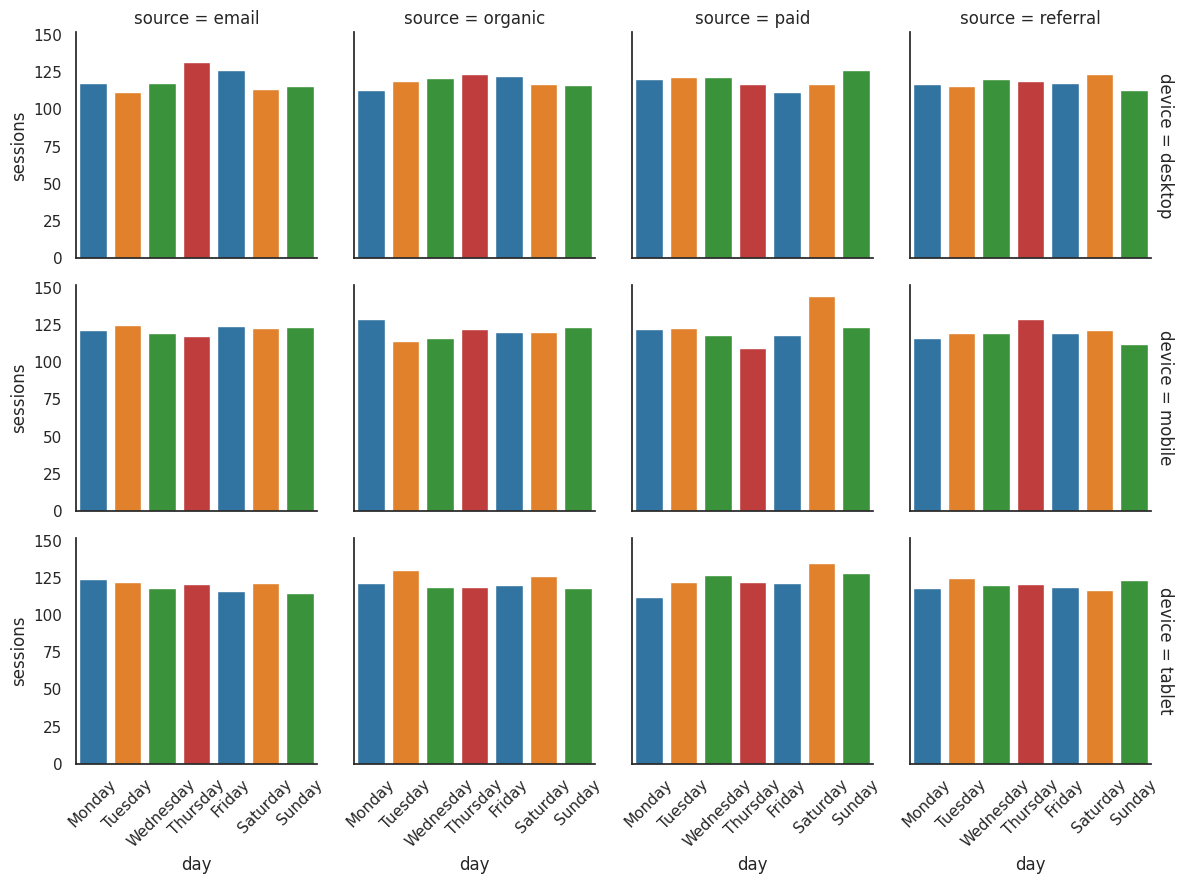

2026-03-15 18:31:44,725: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:31:44,726: INFO - 36) [Variation]: 3 of 4
2026-03-15 18:32:01,990: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:32:01,991: INFO - 36) [Variation]: 4 of 4


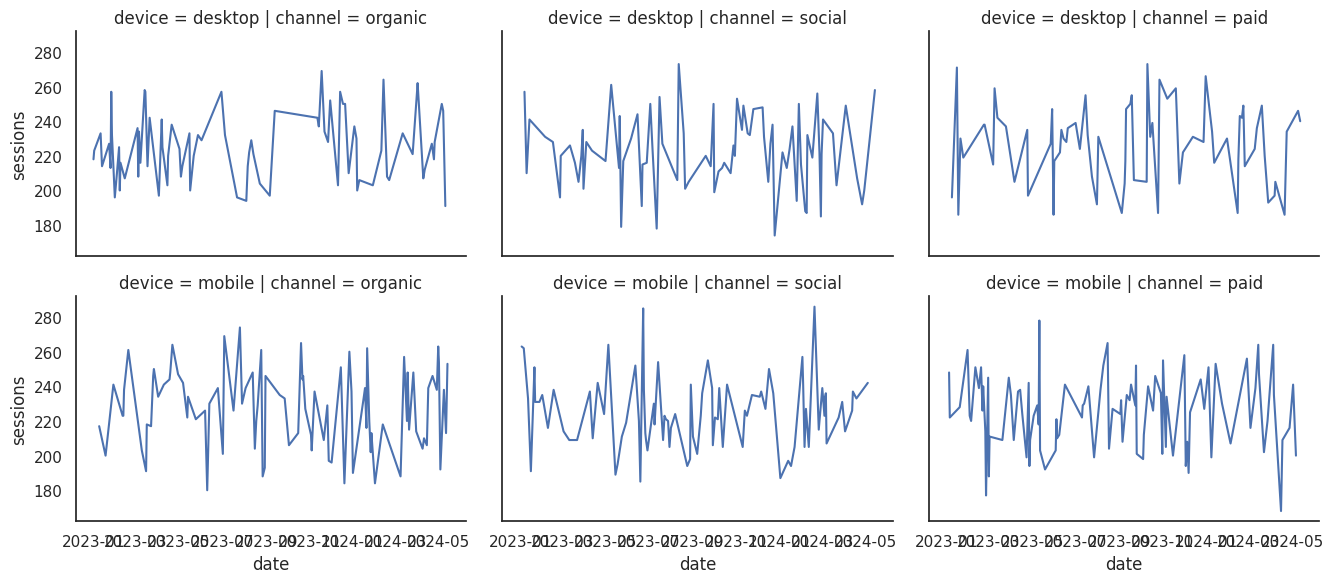

2026-03-15 18:32:19,184: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:32:19,185: INFO - [NEW] chosen/rejected DPO pair added size: 28
2026-03-15 18:32:19,185: INFO - 
37) [EDA Question]: Build a FacetGrid from the operations dataset to compare the distribution or
trend of a numeric feature across different category levels.

2026-03-15 18:32:19,186: INFO - 37) [Variation]: 1 of 4
2026-03-15 18:32:32,850: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:32:32,851: INFO - 37) [Variation]: 2 of 4


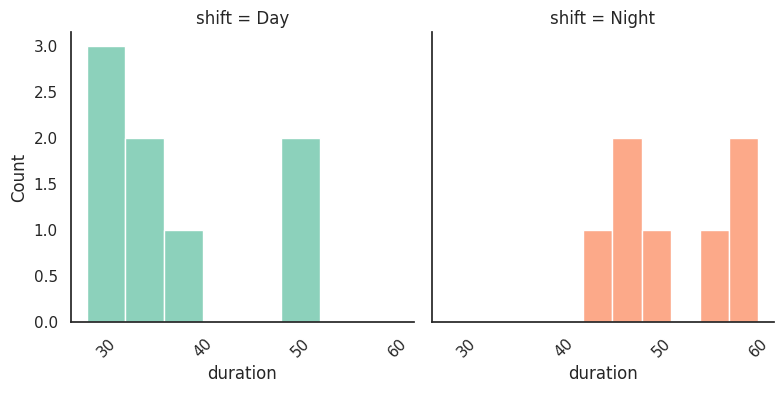

2026-03-15 18:32:52,237: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:32:52,239: INFO - 37) [Variation]: 3 of 4
2026-03-15 18:33:09,273: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:33:09,274: INFO - 37) [Variation]: 4 of 4
2026-03-15 18:33:26,259: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:33:26,260: INFO - [NEW] chosen/rejected DPO pair added size: 29
2026-03-15 18:33:26,262: INFO - 
38) [EDA Question]: You are a senior data analyst. Using seaborn's FacetGrid, plot a metric from the
operations data faceted by one or two categorical variables (e.g., row/column
facets). Store the resul

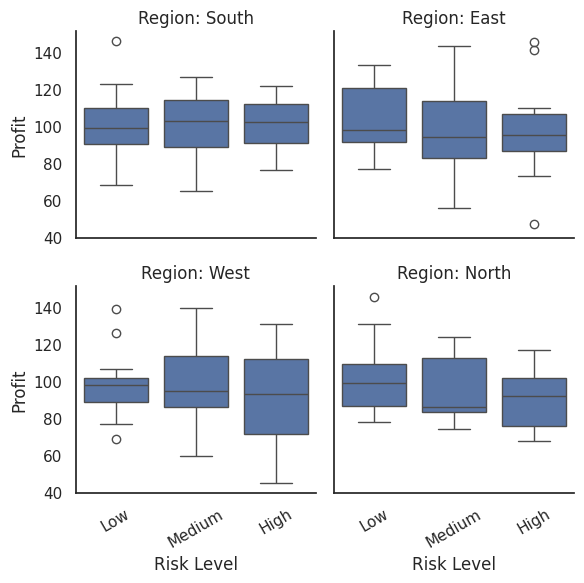

2026-03-15 18:35:00,297: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:35:00,299: INFO - 39) [Variation]: 3 of 4
2026-03-15 18:35:14,379: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:35:14,380: INFO - 39) [Variation]: 4 of 4


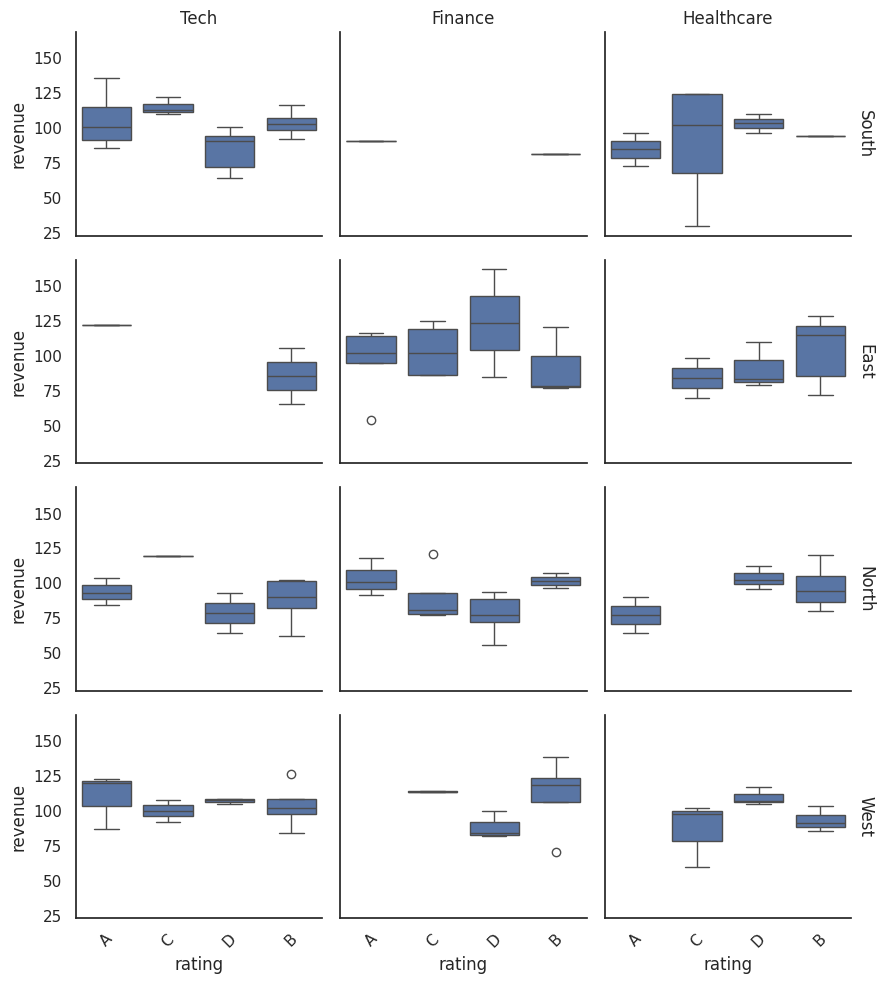

2026-03-15 18:35:31,233: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:35:31,234: INFO - [NEW] chosen/rejected DPO pair added size: 31
2026-03-15 18:35:31,237: INFO - 
40) [EDA Question]: You are a senior data analyst. Create a seaborn FacetGrid for the life_sciences
dataset that shows the relationship between a numeric variable and a category
across multiple subplots.

2026-03-15 18:35:31,238: INFO - 40) [Variation]: 1 of 4
2026-03-15 18:35:45,058: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:35:45,059: INFO - 40) [Variation]: 2 of 4
2026-03-15 18:36:01,775: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                  

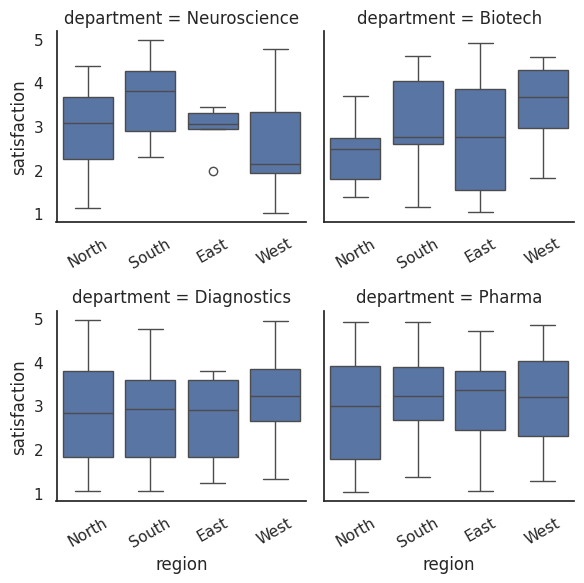

2026-03-15 18:36:34,716: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:36:34,717: INFO - [NEW] chosen/rejected DPO pair added size: 32
2026-03-15 18:36:34,718: INFO - 
41) [EDA Question]: For our upcoming presentation, For the web_traffic time series data, resample to
a specified interval using pandas and calculate aggregated statistics for a
numeric column. Focus on writing performant and vectorized code.

2026-03-15 18:36:34,719: INFO - 41) [Variation]: 1 of 4
2026-03-15 18:36:49,992: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:36:49,993: INFO - 41) [Variation]: 2 of 4
<string>:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:28: FutureWarning: 'M' is deprec

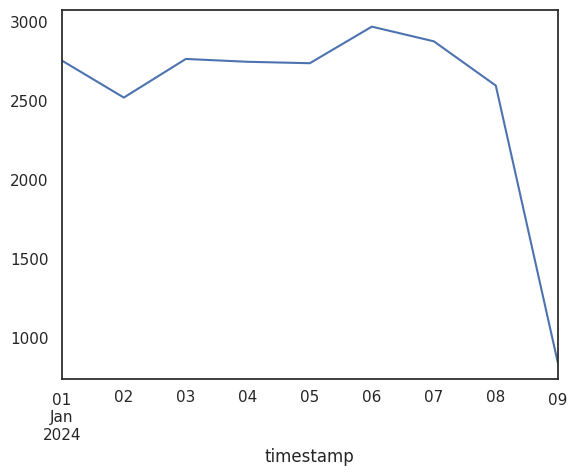

2026-03-15 18:37:21,082: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:37:21,083: INFO - 41) [Variation]: 3 of 4
2026-03-15 18:37:38,789: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:37:38,790: INFO - 41) [Variation]: 4 of 4
<string>:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.


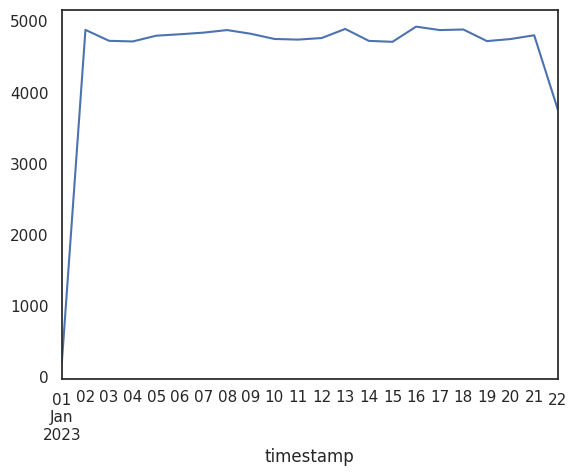

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


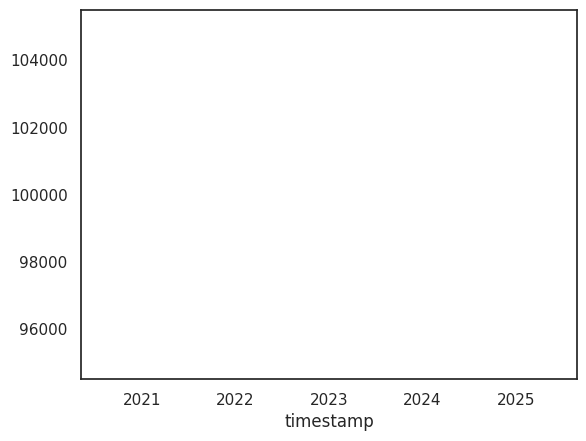

2026-03-15 18:38:03,472: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:38:03,473: INFO - [NEW] chosen/rejected DPO pair added size: 33
2026-03-15 18:38:03,474: INFO - 
42) [EDA Question]: I need some quick help with this. Using pandas, resample the time-indexed
web_traffic data to a coarser frequency (such as daily or monthly) and determine
aggregates like sum and mean. Focus on writing performant and vectorized code.

2026-03-15 18:38:03,475: INFO - 42) [Variation]: 1 of 4
2026-03-15 18:38:18,177: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:38:18,178: INFO - 42) [Variation]: 2 of 4
<string>:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:28: FutureWarning: '

timestamp
2023-01-01     784
2023-01-08    4744
2023-01-15    3936
2023-01-22    4224
2023-01-29    4469
Freq: W-SUN, Name: page_views, dtype: int64
            monthly_total_views  monthly_avg_views  monthly_peak_views
timestamp                                                             
2023-01-31                19206         619.548387                 949
2023-02-28                16806         600.214286                 982
2023-03-31                15961         514.870968                 996
2023-04-30                16617         553.900000                 981
2023-05-31                16143         520.741935                 961


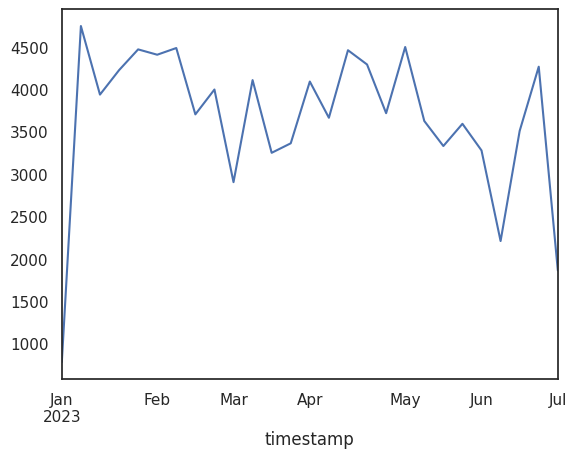

2026-03-15 18:39:43,501: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:39:43,502: INFO - 43) [Variation]: 3 of 4
2026-03-15 18:39:59,545: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:39:59,546: INFO - 43) [Variation]: 4 of 4


            monthly_total_visits  monthly_avg_visits  monthly_min_visits  \
date                                                                       
2024-01-31                  4495               145.0                 100   
2024-02-29                  6815               235.0                 193   
2024-03-31                  9705               323.5                 280   

            monthly_max_visits  
date                            
2024-01-31                 190  
2024-02-29                 277  
2024-03-31                 367  


<string>:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.


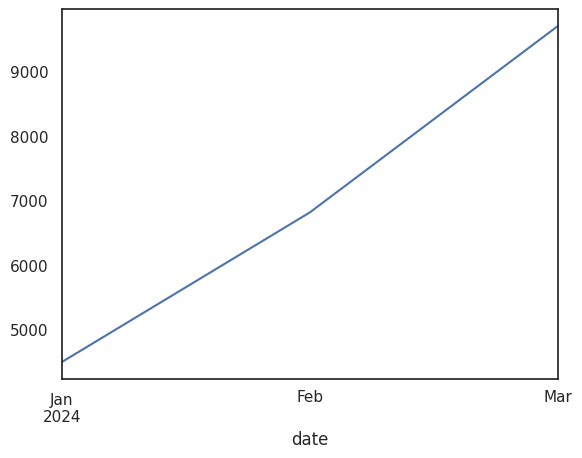

2026-03-15 18:40:17,018: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:40:17,021: INFO - [NEW] chosen/rejected DPO pair added size: 35
2026-03-15 18:40:17,022: INFO - 
44) [EDA Question]: For our upcoming presentation, With pandas, take the web_traffic dataset indexed
by timestamps and resample it to a regular frequency, computing summary metrics
for each period. Make sure to handle any missing values properly.

2026-03-15 18:40:17,023: INFO - 44) [Variation]: 1 of 4
2026-03-15 18:40:34,341: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:40:34,342: INFO - 44) [Variation]: 2 of 4
<string>:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:22: FutureWarning: Series.f

                           visits_sum  visits_mean  visits_max  visits_min  \
timestamp                                                                    
2023-01-01 00:00:00+00:00      1210.0    50.416667        71.0        39.0   
2023-01-02 00:00:00+00:00      1217.5    50.729167        65.0        38.0   
2023-01-03 00:00:00+00:00      1167.5    48.645833        67.0        33.0   
2023-01-04 00:00:00+00:00      1249.5    52.062500        66.0        39.0   
2023-01-05 00:00:00+00:00      1182.5    49.270833        66.0        37.0   

                           pageviews_sum  pageviews_mean  pageviews_max  \
timestamp                                                                 
2023-01-01 00:00:00+00:00         2973.0      123.875000          147.0   
2023-01-02 00:00:00+00:00         2927.0      121.958333          152.0   
2023-01-03 00:00:00+00:00         2917.0      121.541667          139.0   
2023-01-04 00:00:00+00:00         2944.5      122.687500          141.0   
202

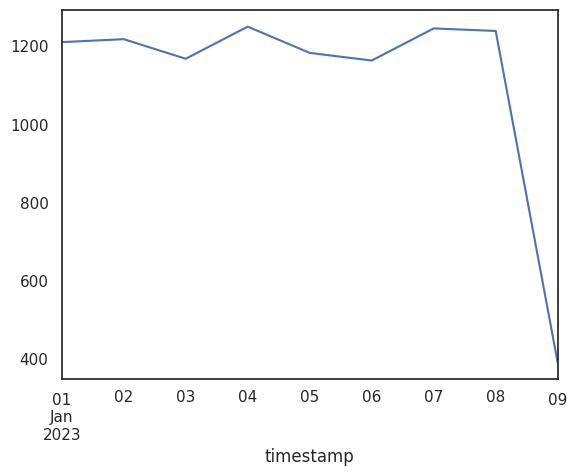

2026-03-15 18:41:04,900: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:41:04,902: INFO - 44) [Variation]: 3 of 4
2026-03-15 18:41:31,625: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:41:31,627: INFO - 44) [Variation]: 4 of 4
<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.


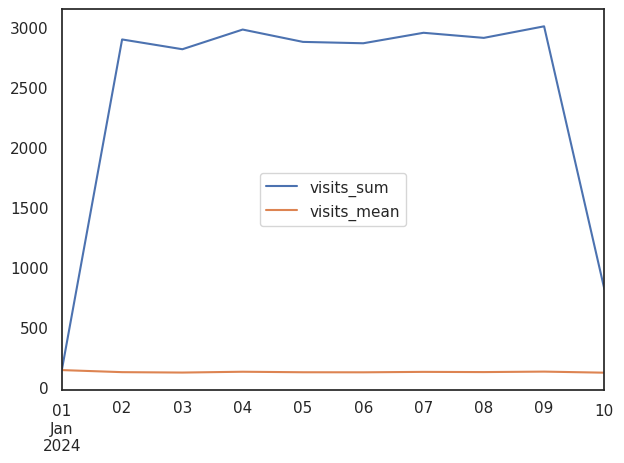

2026-03-15 18:41:50,819: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:41:50,820: INFO - [NEW] chosen/rejected DPO pair added size: 36
2026-03-15 18:41:50,820: INFO - 
45) [EDA Question]: Using pandas, resample the time-indexed HR data to a coarser frequency (such as
daily or monthly) and compute aggregates like sum and mean. Reset the index of
the resulting DataFrame.

2026-03-15 18:41:50,821: INFO - 45) [Variation]: 1 of 4
2026-03-15 18:42:11,934: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:42:11,935: INFO - 45) [Variation]: 2 of 4
<string>:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
2026-03-15 18:42:31,986: INFO - Scoring for variation 2:
                      

                   datetime      hr      
                                sum  mean
0 2024-01-01 00:00:00+00:00  1716.0  71.5
1 2024-01-02 00:00:00+00:00  1752.0  73.0
2 2024-01-03 00:00:00+00:00  1788.0  74.5
3 2024-01-04 00:00:00+00:00  1824.0  76.0
4 2024-01-05 00:00:00+00:00  1860.0  77.5
5 2024-01-06 00:00:00+00:00  1716.0  71.5
6 2024-01-07 00:00:00+00:00  1752.0  73.0
7 2024-01-08 00:00:00+00:00  1788.0  74.5


2026-03-15 18:42:47,662: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:42:47,663: INFO - 45) [Variation]: 4 of 4
<string>:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
<string>:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
2026-03-15 18:43:09,800: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:43:09,801: INFO - [NEW] chosen/rejected DPO pair added size: 37
2026-03-15 18:43:09,803: INFO - 
46) [EDA Question]: You are a senior data analyst. From the life_sciences time series data, create a
matplotlib plot showing the original values and a moving average on the same
axes. Please ensure the code is well-commented.

2

                      index  HR_sum    HR_mean
0 2023-01-01 00:00:00+00:00    1933  80.541667
1 2023-01-02 00:00:00+00:00    1925  80.208333
2 2023-01-03 00:00:00+00:00    1914  79.750000
3 2023-01-04 00:00:00+00:00    1858  77.416667
4 2023-01-05 00:00:00+00:00    1923  80.125000
                      index  HR_sum  HR_mean
0 2023-01-31 00:00:00+00:00   15874    79.37


2026-03-15 18:43:24,156: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:43:24,157: INFO - 46) [Variation]: 2 of 4


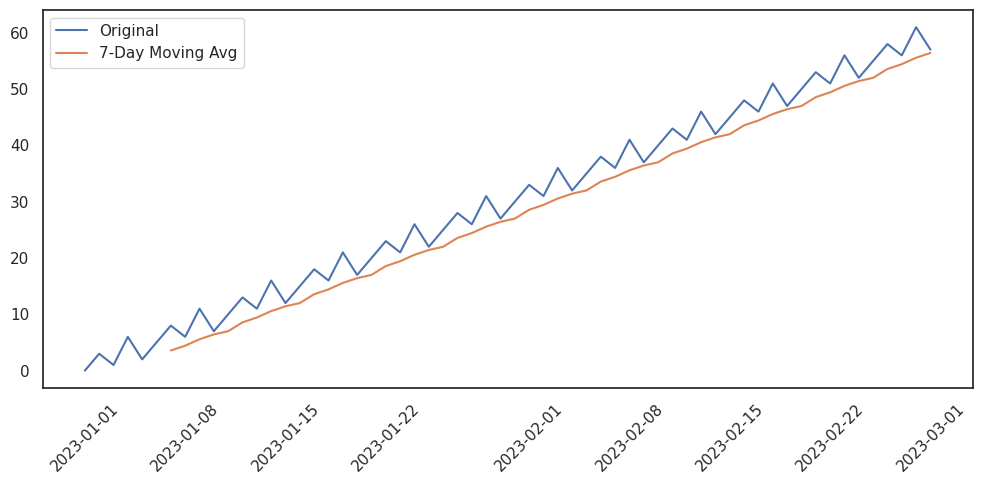

2026-03-15 18:43:42,086: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:43:42,087: INFO - 46) [Variation]: 3 of 4
2026-03-15 18:43:57,062: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:43:57,063: INFO - 46) [Variation]: 4 of 4
<string>:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.


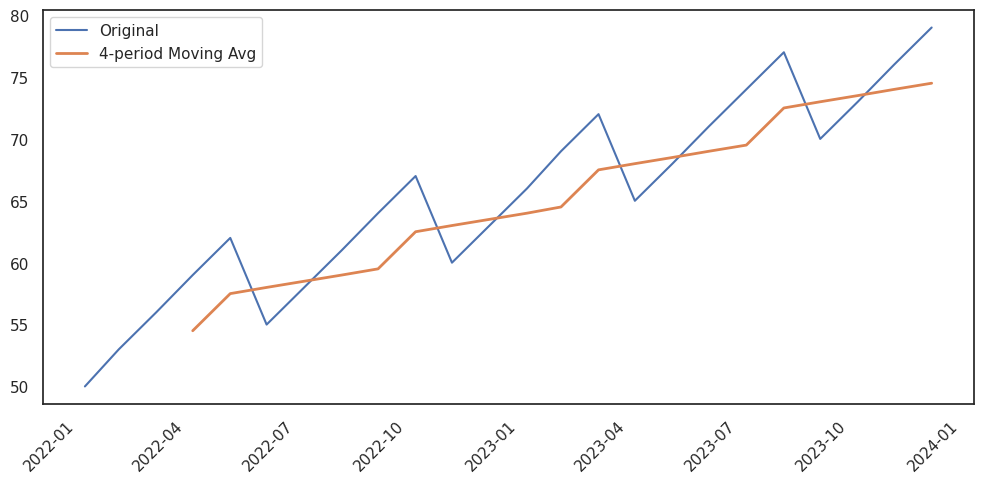

2026-03-15 18:44:14,788: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:44:14,789: INFO - [NEW] chosen/rejected DPO pair added size: 38
2026-03-15 18:44:14,792: INFO - 
47) [EDA Question]: Using pandas and matplotlib, plot a line chart of a time series from the finance
data and overlay a rolling mean for smoothing. Reset the index of the resulting
DataFrame.

2026-03-15 18:44:14,792: INFO - 47) [Variation]: 1 of 4
2026-03-15 18:44:32,637: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:44:32,638: INFO - 47) [Variation]: 2 of 4
2026-03-15 18:44:51,245: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-1

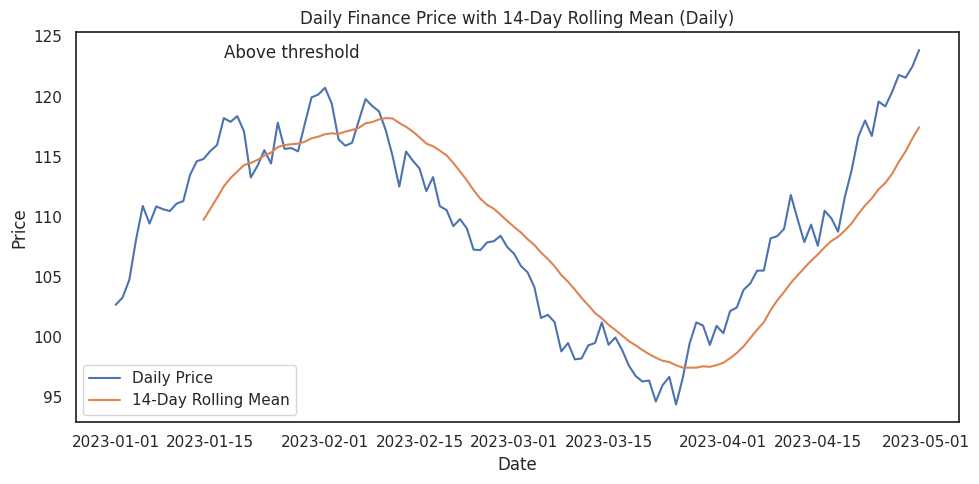

2026-03-15 18:45:23,466: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:45:23,469: INFO - [NEW] chosen/rejected DPO pair added size: 39
2026-03-15 18:45:23,470: INFO - 
48) [EDA Question]: Using pandas and matplotlib, plot a line chart of a time series from the
life_sciences data and overlay a rolling mean for smoothing. Avoid chained
indexing and explicitly use .loc.

2026-03-15 18:45:23,470: INFO - 48) [Variation]: 1 of 4
2026-03-15 18:45:38,932: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:45:38,933: INFO - 48) [Variation]: 2 of 4


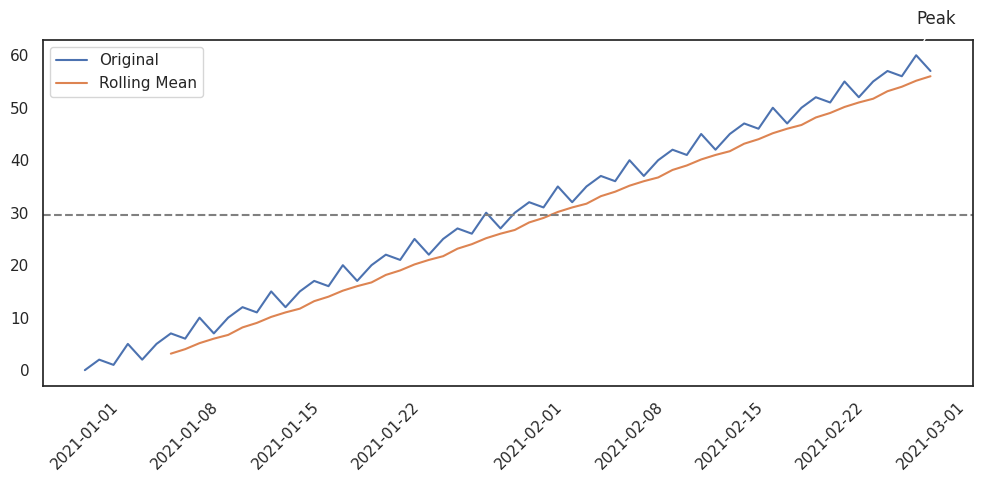

2026-03-15 18:45:58,094: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:45:58,096: INFO - 48) [Variation]: 3 of 4
2026-03-15 18:46:12,611: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:46:12,612: INFO - 48) [Variation]: 4 of 4


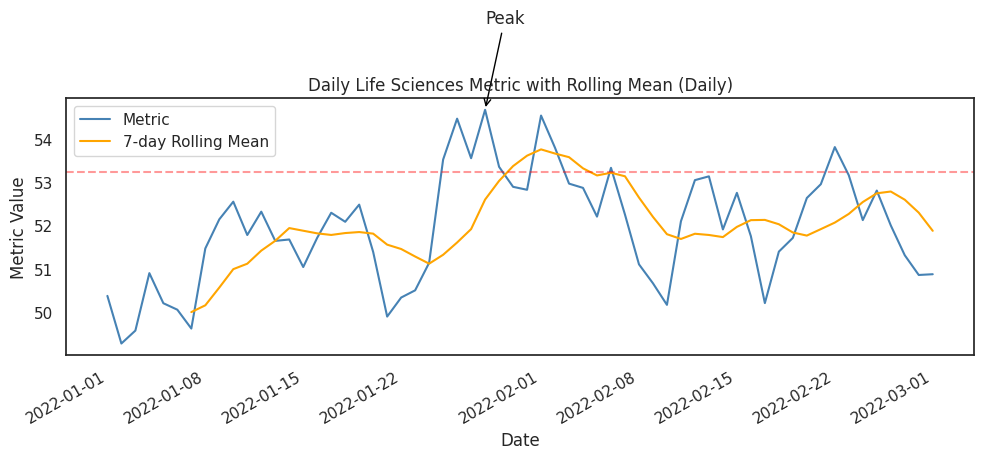

2026-03-15 18:46:27,763: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:46:27,765: INFO - [NEW] chosen/rejected DPO pair added size: 40
2026-03-15 18:46:27,765: INFO - 
49) [EDA Question]: As part of a data pipeline, From the life_sciences time series data, create a
matplotlib plot showing the original values and a moving average on the same
axes. Make sure to handle any missing values properly.

2026-03-15 18:46:27,766: INFO - 49) [Variation]: 1 of 4
2026-03-15 18:46:42,411: INFO - Scoring for variation 1:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:46:42,412: INFO - 49) [Variation]: 2 of 4


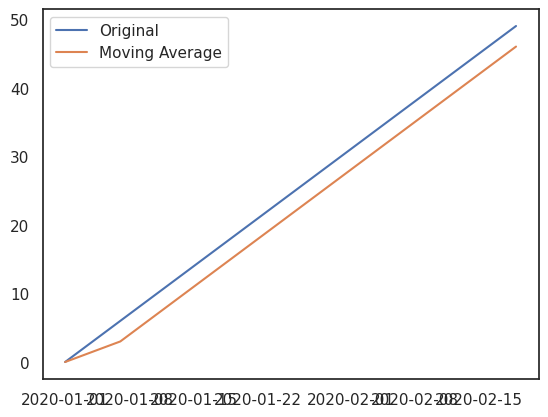

2026-03-15 18:46:59,431: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:46:59,432: INFO - 49) [Variation]: 3 of 4
2026-03-15 18:47:14,347: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:47:14,348: INFO - 49) [Variation]: 4 of 4
2026-03-15 18:47:29,518: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:47:29,519: INFO - [NEW] chosen/rejected DPO pair added size: 41
2026-03-15 18:47:29,520: INFO - 
50) [EDA Question]: As part of a data pipeline, Plot a time series from the life_sciences data with
pandas/matplotlib, including both the raw series and a rolling-window average to
highlight trends. Foc

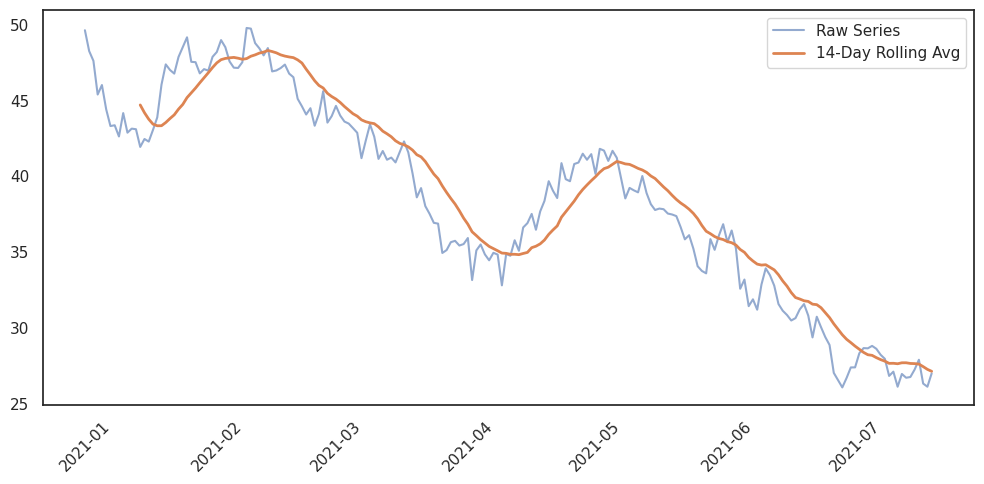

2026-03-15 18:48:00,294: INFO - Scoring for variation 2:
                        from [google/gemini-3.1-pro-preview]:: 4
                        from 'test_code':: True
                    
2026-03-15 18:48:00,295: INFO - 50) [Variation]: 3 of 4
2026-03-15 18:48:15,669: INFO - Scoring for variation 3:
                        from [google/gemini-3.1-pro-preview]:: 2
                        from 'test_code':: False
                    
2026-03-15 18:48:15,670: INFO - 50) [Variation]: 4 of 4


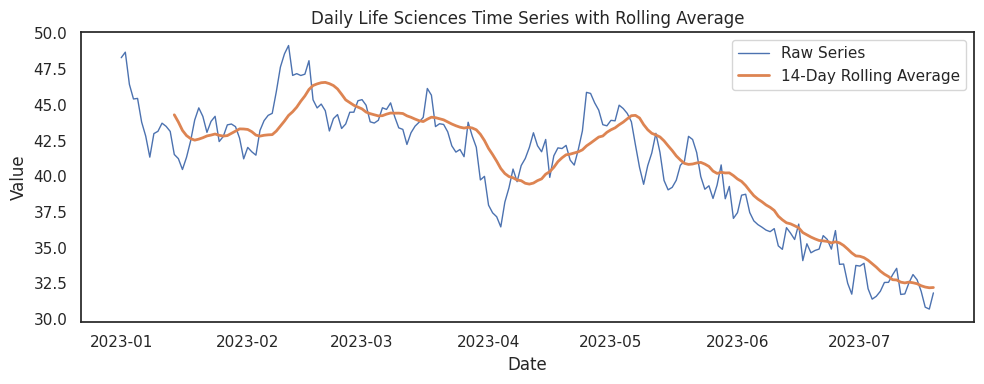

2026-03-15 18:48:30,881: INFO - Scoring for variation 4:
                        from [google/gemini-3.1-pro-preview]:: 5
                        from 'test_code':: True
                    
2026-03-15 18:48:30,882: INFO - [NEW] chosen/rejected DPO pair added size: 42
2026-03-15 18:48:31,090: INFO - 

 [DONE] - Saved augmented_dpo_df to : /content/drive/MyDrive/Colab Notebooks/DS552/project/data/pandas_dpo_datasetv22.0.jsonl




In [ ]:
from IPython.display import Javascript, display
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 800})'''))

# Final df for DPO pairs
augmented_dpo_pairs = pd.DataFrame(columns=['prompt', 'chosen', 'rejected'])
jsonl_dataset = data_dir + "/pandas_dpo_datasetv" + str(CUR_DS_VERSION+1) + ".0.jsonl"
# Create 4x candidates per prompt
new_dpo_pairs = await main(n=4)

if len(new_dpo_pairs) > 0:
  new_dpo_df = pd.DataFrame(new_dpo_pairs)
  old_dpo_df = base_dpo_ds.to_pandas()
  augmented_dpo_df = pd.concat([old_dpo_df, new_dpo_df], ignore_index=True)
  augmented_dpo_df.to_json(jsonl_dataset, orient="records", lines=True, force_ascii=False)
  logger.info(f"\n\n [DONE] - Saved augmented_dpo_df to : {jsonl_dataset}\n\n")
else:
  logger.info("\nNO new DPO pairs to add")

In [ ]:
base_dpo_ds.shape, augmented_dpo_df.shape

((2840, 3), (2882, 3))